In [31]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle
from collections import Counter
from scipy.stats import spearmanr

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/camp/home/tootoos/working/tootoos/conda-envs/numpyro-env/lib/python3.10/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['split', 'f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [3]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [187]:
from odours import odours
import driver; reload(driver)
from driver import RunResults

# Figure for the Paper

In [5]:
def vld_fun_ratio(vld):
    in_out = np.mean((vld.Cin - vld.Cstar)**2)**0.5
    est_out=np.mean((vld.Cest - vld.Cstar)**2)**0.5
    return in_out, est_out 

def vld_fun_corr(corrs):
    in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
    est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
    return in_out, est_out

def compute_corr_energ_(C):
    # If C is a square matrix, use the off-diagonal elements to compute the energy
    if C.shape[0] == C.shape[1]:
        total_energy = np.sum(C**2) - np.sum(np.diag(C)**2)
        n_elements = C.shape[0] * (C.shape[0] - 1)
        return total_energy / n_elements
    else:
        # If C is not square, compute the energy using all elements
        return np.mean(C**2)
        
def vld_fun_corr_energy(corrs):
    [in_, out_, est_] = [compute_corr_energ_(corrs[key]) for key in ["Cin", "Cstar", "Cest"]]
    return in_, out_, est_

In [6]:
import layout; reload(layout)
import results; reload(results)
selection_metric = "ratio"
splits = [
    ("trials", "random", "max"),
    ("odours", "random", "max"),
    ("odours", "inclass", "max"),
    ("odours", "outclass", "max")
] 
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits-scatter", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)

## Load the covariance metric dataframe

In [7]:
which_models = ["Diag", "DiagOnlyInh", "Free", "FreeLat"]
compute_df = False
if compute_df:
    # Import cartesiaon product
    from itertools import product
    selection_metric = "ratio"
    records = []
    for split_name in splits:
        split = base.split(*split_name)
        for model_name in which_models:
            model   = split.model(model_name)
            n_train = len(model.df["ref"].unique())
            #report  = model.report(metric=selection_metric, extra_fields = ["outclass"] if "outclass" in split_name else [])     
            n_seeds = len(model.df["seed"].unique())
            # I wanted to use report to get the best parameter values, but extract already does that.
            # All in need to know is whether to include the outclass
            outclasses = model.df["outclass"].unique()
            iterable = product(range(n_seeds), range(n_train), outclasses)
            for seed, train, outclass in tqdm(iterable, total=n_seeds*n_train*len(outclasses)):
                extra_fields = {"outclass":outclass} if "outclass" in split_name else {}
                #print(f"{split_name}, {model_name}, seed={seed}, train={train}, outclass={outclass}")
                res = model.extract(seed=seed, train=train, la="min" if model_name.startswith("Diag") else None, metric=selection_metric, **extra_fields)
                cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
                corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
                corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)
                records.append({
                    "sampler": split_name[0],
                    "mode": split_name[1],
                    "n_od_train": split_name[2],
                    "model": model_name,
                    "seed": seed,
                    "train": train,
                    "outclass": outclass,
                    "cov_in_out": cov_in_out,
                    "cov_est_out": cov_est_out,
                    "corr_in_out": corr_in_out,
                    "corr_est_out": corr_est_out,
                    "corr_en_in": corr_en_in,
                    "corr_en_out": corr_en_out,
                    "corr_en_est": corr_en_est
                })
    df = pd.DataFrame(records)
    # Save the df to disk
    with open(proj_path + "/model-fitting/generalization_results.pkl", "wb") as f:
        pickle.dump(df, f)


In [8]:
# Save the df to disk
with open(proj_path + "/model-fitting/generalization_results.pkl", "rb") as f:
    df = pickle.load(f)

In [9]:
df.head()

,sampler,mode,n_od_train,model,seed,train,outclass,cov_in_out,cov_est_out,corr_in_out,corr_est_out,corr_en_in,corr_en_out,corr_en_est
0,trials,random,max,Diag,0,0,None,55.804779,27.100118,0.304090,0.175526,0.268415,0.079588,0.102576
1,trials,random,max,Diag,0,1,None,56.364182,28.232228,0.304578,0.177283,0.268415,0.080531,0.102576
2,trials,random,max,Diag,0,2,None,56.652894,28.228552,0.306596,0.178066,0.268415,0.078880,0.102576
3,trials,random,max,Diag,0,3,None,56.039460,27.652558,0.305300,0.176380,0.268415,0.080032,0.102576
4,trials,random,max,Diag,0,4,None,55.703823,27.416923,0.305495,0.177980,0.268415,0.080832,0.102576


## Plot covariance metrics

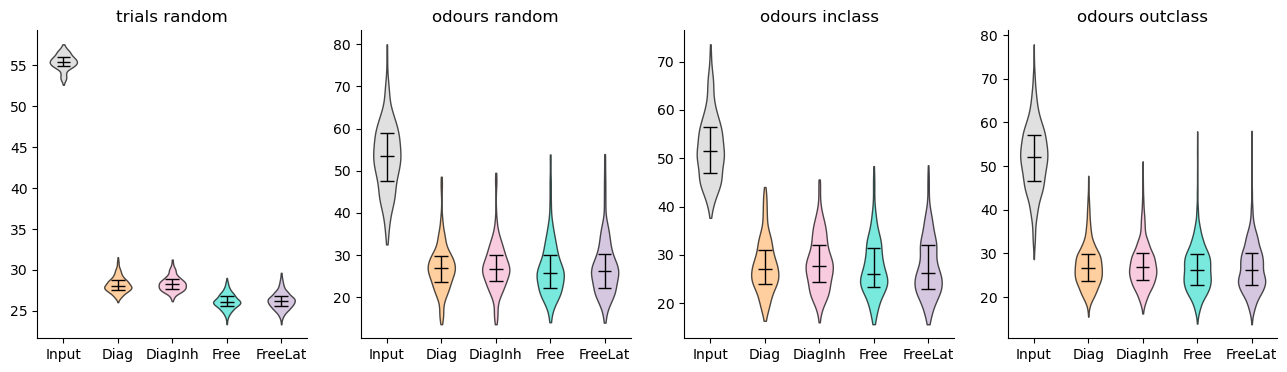

In [10]:
import figures; reload(figures)
from figures import ViolinPlotData, violin_plots, scatter_plot
import proc_fit_models as pfm; reload(pfm)
prefix = "cov"
assert prefix in ["cov", "corr", "corr_en"], "prefix must be one of 'cov', 'corr', or 'corr_en'"
nr, nc = 1, 4
fig, ax = plt.subplots(nrows=nr, ncols=nc, figsize=((4+ 0.5*(prefix=="corr_en")) * nc, 4 * nr))
split_descr = {"trials": ("trials", "random"),
               "odours_random,": ("odours", "random"),
               "odours_inclass": ("odours", "inclass"),
               "odours_outclass": ("odours", "outclass")}
order = ["trials", "odours_random,", "odours_inclass", "odours_outclass"]
model_labs = {"Diag": "Diag",
              "DiagOnlyInh": "DiagInh",
              "Free": "Free",
              "FreeLat": "FreeLat"}
model_names = list(model_labs.keys())
which_models = list(model_labs.keys())
cols = ["Gray"] + [pfm.model_color(m) for m in model_names] 
for i, (axi, split_name) in enumerate(zip(ax.flatten(), order)):
    sampler, mode = split_descr[split_name]
    split_mask = (df["sampler"] == sampler) & (df["mode"] == mode) 
    if prefix in ["cov", "corr"]:
        in_out       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
        models_est_out = [df[split_mask & (df['model']==m)][f"{prefix}_est_out"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(in_out, "LightGray", "Input")] + [ViolinPlotData(models_est_out[i], pfm.model_color(model_names[i]), model_labs[model_names[i]]) for i in range(len(model_names))])
    else:
        en_in       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in"].values
        en_out      = df[split_mask & (df['model']=="Diag")][f"{prefix}_out"].values
        en_est_models = [df[split_mask & (df['model']==m)][f"{prefix}_est"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(en_in, "LightGray", "Input")] + [ViolinPlotData(en_est_models[i], pfm.model_color(model_names[i]), model_labs[model_names[i]]) for i in range(len(model_names))] + [ViolinPlotData(en_out, "Gray", "Output")])
        axi.set_ylim((0, 0.45))
    axi.set_title(f"{sampler} {mode}")
    #i >0 and axi.set_ylim((0, 0.5) if prefix=="corr" else (0, 80))
    [axi.spines[spine].set_visible(False) for spine in ['top', 'right']]

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits-scatter/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits-scatter/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=random/n_od_train=max/loaded_models.p.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits-scatter/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=inclass/n_od_train=max/loaded_models.p.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits-scatter/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=outclass/n_od_train=max/loaded_models.p.


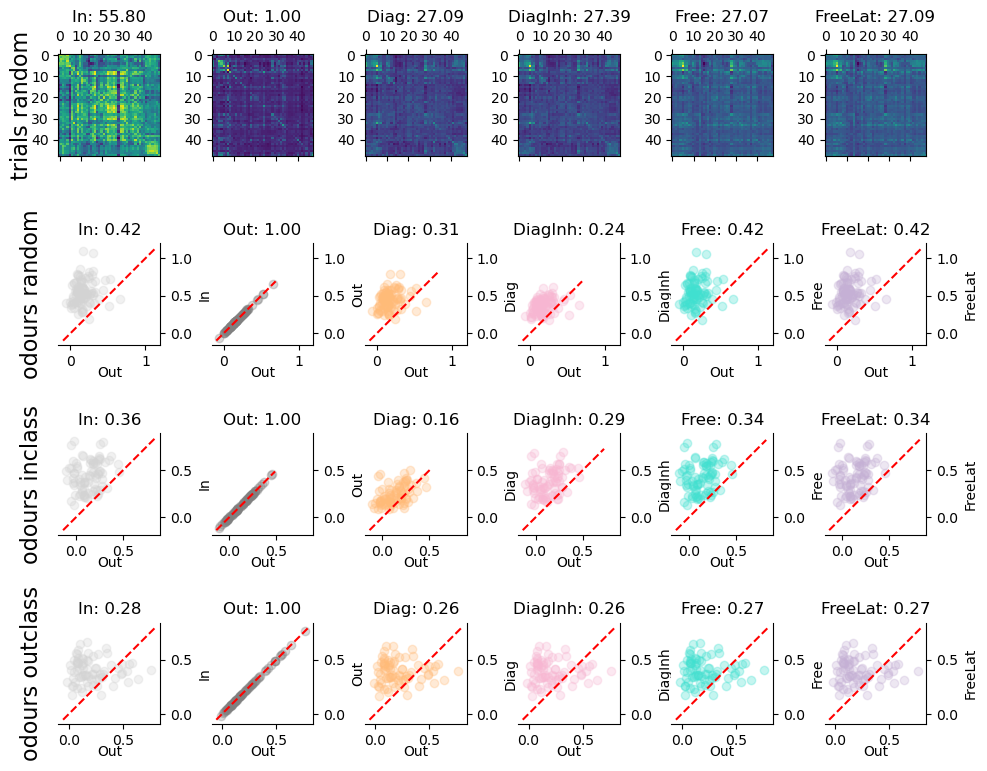

In [11]:
reload(figures)
from figures import scatter_plot
fig, ax = plt.subplots(nrows=4, ncols=len(which_models)+2, figsize=(10, 8))
vmin = {"cov": None, "corr": 0, "corr_en": 0}
vmax = {"cov": None, "corr": 1, "corr_en": 1}
cmap = {"cov": "viridis", "corr": "bwr", "corr_en": "bwr"}
ttls = ["In", "Out"] + [model_labs[m] for m in which_models]
append_to_title = lambda ax, s: ax.set_title(ax.get_title() + s)
prepend_to_title = lambda ax, s: ax.set_title(s + ax.get_title())
for i, split_name in enumerate(order):
    descr = split_descr[split_name]
    split = base.split(sampler=descr[0], mode=descr[1], n_od_train="max")
    extra_fields = {"outclass":"Ketone"} if "outclass" in split_name else {}
    for j, name in enumerate(which_models):
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
        corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)

        vals = covs if prefix == "cov" else corrs
        matshow_kwargs = {"vmin": vmin[prefix], "vmax": vmax[prefix], "cmap": cmap[prefix]} 
        plot_fun = lambda ax, k, ylab, c: (ax.matshow(vals[k], **matshow_kwargs), ax.set_xticks(np.arange(0,50,10)), ax.set_yticks(np.arange(0,50,10))) if i == 0 else scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val  = {"cov":cov_in_out, "corr":corr_in_out, "corr_en":corr_en_in}[prefix]
        est_val = {"cov":cov_est_out, "corr":corr_est_out, "corr_en":corr_en_est}[prefix]
        out_val = {"cov":1., "corr":1., "corr_en":corr_en_out}[prefix]

        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "LightGray")
            ax[i,0].set_title(f"In: {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "Gray")
            ax[i,1].set_title(f"Out: {out_val:.2f}")

        plot_fun(ax[i,2+j], "Cest", ttls[j+2], pfm.model_color(name))
        ax[i,2+j].set_title(f"{ttls[j+2]}: {est_val:.2f}")
    if i > 0:
        # Share the x and y lims with the first plot in the row
        for j in range(2 + len(which_models)):
            ax[i,j].set_xlim(ax[i,0].get_xlim())
            ax[i,j].set_ylim(ax[i,0].get_ylim())
            ax[i,j].set_aspect('equal')
            # Turn top and right spines off
            [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{descr[0]} {descr[1]}", va='center', ha='right', 
                fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0)


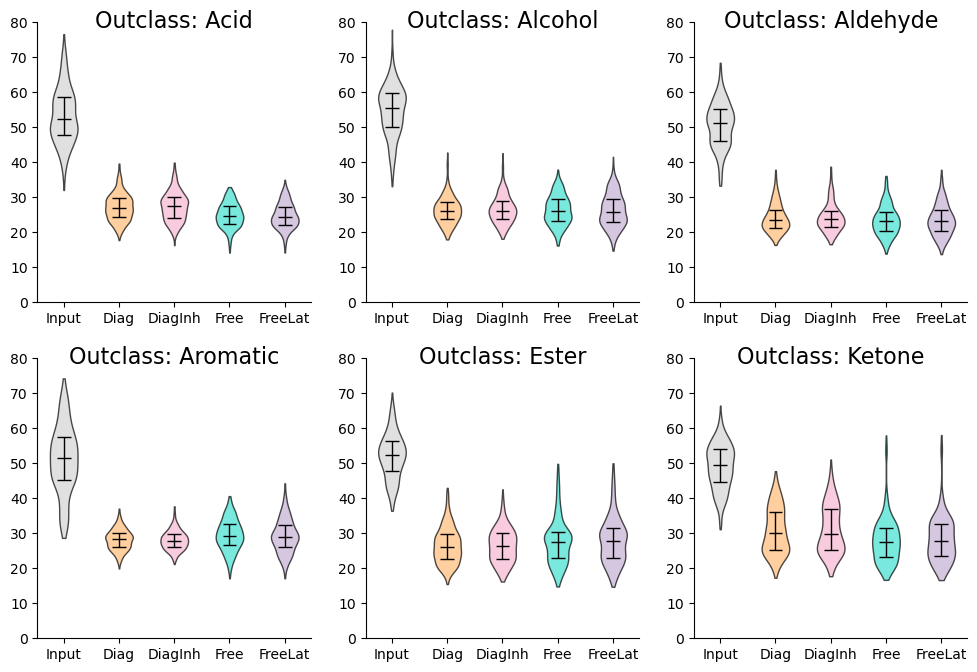

In [12]:
# Now just look at outclass, by outclass
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
outclasses = sorted(df[df.outclass.notnull()]["outclass"].unique())
for i, (axi, outclass) in enumerate(zip(ax.flatten(), outclasses)):
    split_mask = (df["sampler"] == "odours") & (df["mode"] == "outclass") & (df["outclass"] == outclass)

    if prefix in ["cov", "corr"]:
        in_out       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
        models_est_out = [df[split_mask & (df['model']==m)][f"{prefix}_est_out"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(in_out, "LightGray", "Input")] + [ViolinPlotData(est_out, pfm.model_color(m), model_labs[m]) for est_out, m in zip(models_est_out, model_names)])
    else:
        en_in       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in"].values
        en_out      = df[split_mask & (df['model']=="Diag")][f"{prefix}_out"].values
        en_models   = [df[split_mask & (df['model']==m)][f"{prefix}_est"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(en_in, "LightGray", "Input")] + [ViolinPlotData(est, pfm.model_color(m), model_labs[m]) for est, m in zip(en_models, model_names)] + [ViolinPlotData(en_out, "Gray", "Output")])
        #axi.set_ylim((0, 0.45))

    axi.set_title(f"Outclass: {outclass}", fontsize=16, y=0.95)
    axi.set_ylim((0, 0.5) if prefix in["corr", "corr_en"] else (0, 80))
    [axi.spines[spine].set_visible(False) for spine in ['top', 'right']]

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=outclass/n_od_train=max/loaded_models.p.


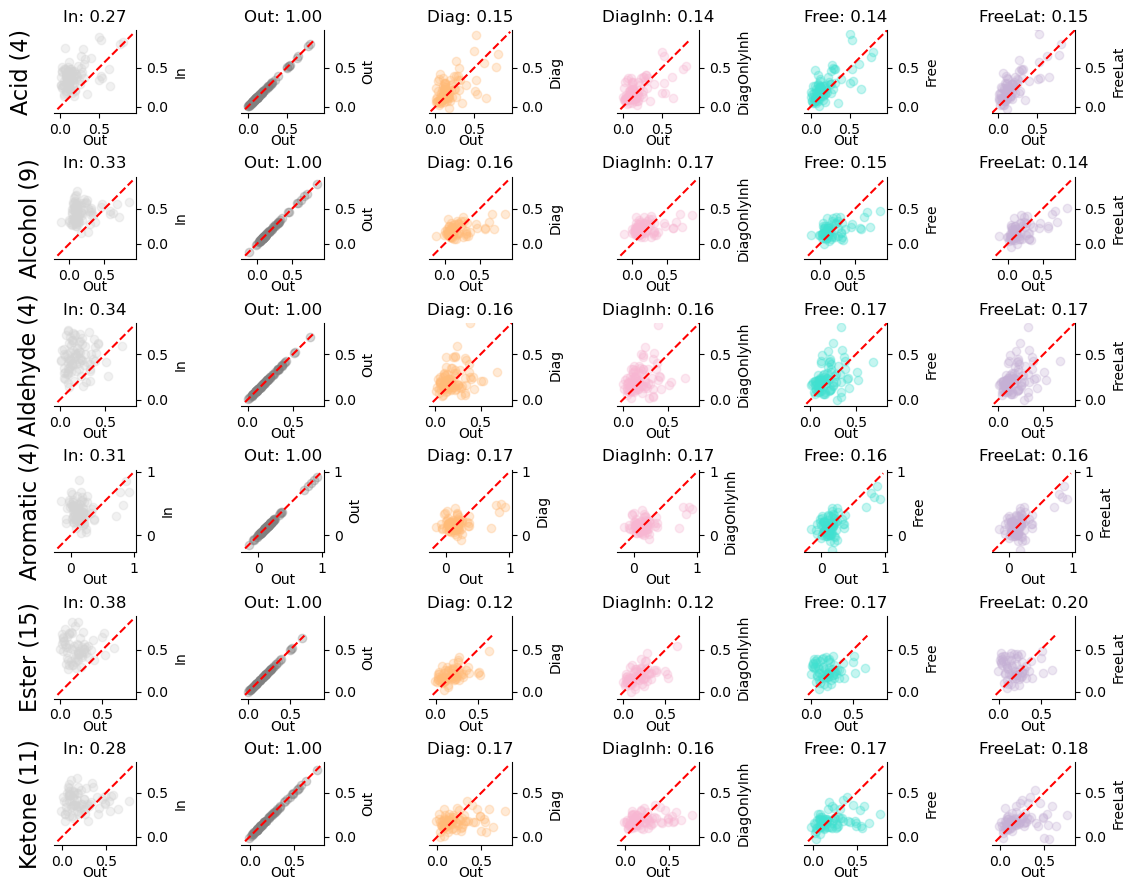

In [13]:
reload(results)
class_counts = Counter(odours.classes)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
fig, ax = plt.subplots(nrows=6, ncols=2+len(which_models), figsize=(12, 9))
split = base.split(sampler="odours", mode="outclass", n_od_train="max")
for i, outclass in enumerate(outclasses): 
    extra_fields = {"outclass": outclass}
    for j, name in enumerate(which_models):
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
        corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)
 
        vals = covs if prefix == "cov" else corrs
        plot_fun = lambda ax, k, ylab, c: scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val = {"cov":cov_in_out, "corr":corr_in_out, "corr_en":corr_en_in}[prefix]
        est_val = {"cov":cov_est_out, "corr":corr_est_out, "corr_en":corr_en_est}[prefix]
        out_val = {"cov":1., "corr":1., "corr_en":corr_en_out}[prefix]
 
        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "LightGray")
            append_to_title(ax[i,0], f": {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "Gray")
            append_to_title(ax[i,1], f": {out_val:.2f}")
            plot_fun(ax[i,2], "Cest", "Diag", pfm.model_color("Diag"))
            append_to_title(ax[i,2], f": {est_val:.2f}")
        else:
            plot_fun(ax[i,2+j], "Cest", name, pfm.model_color(name))
            append_to_title(ax[i,2+j], f": {est_val:.2f}")
    
    [prepend_to_title(axi, ttl) for axi, ttl in zip(ax[i,:], ttls)]

    # Share the x and y lims with the first plot in the row
    for j in range(2 + len(which_models)):
        ax[i,j].set_xlim(ax[i,0].get_xlim())
        ax[i,j].set_ylim(ax[i,0].get_ylim())
        ax[i,j].set_aspect('equal')
        # Turn top and right spines off
        [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{outclass} ({class_counts[outclass]})", va='center', ha='right', 
                 fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0.5)

## Understand the Diag Solution

In [169]:
import results; reload(results)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


### The Regularization Path

In [150]:
df = trials.model("Diag").df
la_vals = sorted(df.λ.unique())
# Get teh regularization path
model = trials.model("Diag")
p_finals = np.array([ model.extract(seed=0, train=0, la=la, metric="r2", with_params=True).params["p_final"] for la in la_vals])

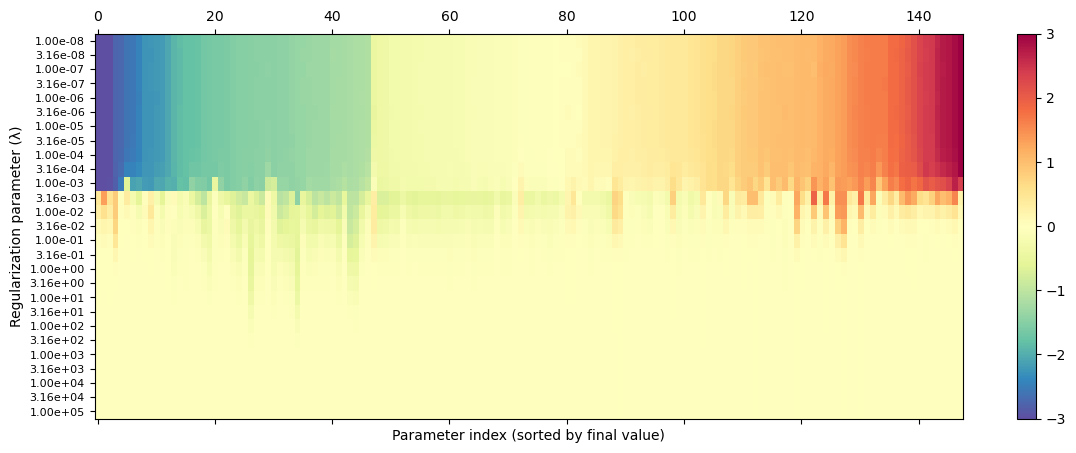

In [146]:
plt.figure(figsize=(14,5))
ii = argsort(p_finals[0])
plt.matshow(p_finals[:, ii] - 1, cmap='Spectral_r', fignum=False, vmin=-3,vmax=3, aspect='auto')
gca().set_yticks(np.arange(len(la_vals)))
gca().set_yticklabels([f"{la:.2e}" for la in la_vals], fontsize=8)
plt.xlabel("Parameter index (sorted by final value)")
ylabel("Regularization parameter (λ)")
# Add a colorbar
cbar = plt.colorbar()

### Verify a solution

In [147]:
in_file = os.path.join(trials.split_dir, "fit_diag", "in.0.p")
print(f"Loading input file: {in_file}")
with open(in_file, "rb") as f:
    inp = pickle.load(f)
inp["sampler"]["n_train"]=1
results, dataset, mdl = driver.run(inp, return_dataset=True, return_model=True)
mdl.results

Loading input file: /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/fit_diag/in.0.p
Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=1, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=1, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing traini

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.012856473565028793
        x: [ 3.630e-01  5.442e-01 ... -1.264e+00 -3.450e+00]
      nit: 175
      jac: [ 4.564e-06  9.704e-06 ...  2.565e-08 -3.158e-07]
     nfev: 197
     njev: 197
 hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>

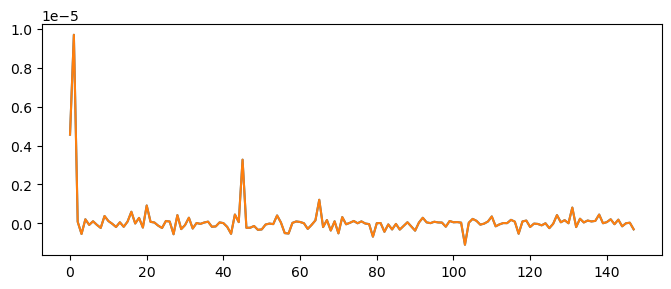

In [148]:
X, Y = dataset["XX"].trains[0], dataset["YY"].trains[0]
z = results["p_final"]
m = X.shape[0]; I = np.eye(m); J = I - np.ones((m, m)) / m
my= Y.shape[0]; Iy = np.eye(my); Jy = Iy - np.ones((my, my)) / my
Y_ = diag(z) @ X
C_ = Y_.T @ J @ Y_
C  = Y.T @ Jy @ Y
assert allclose(mdl.Cstars[0], C)
assert allclose(z, mdl.p)
E = C_ - C
M = X @ E @ X.T
g_pred = 2* diag(J @ diag(z) @ M)/C.shape[0]**2
g_mdl = mdl.JAC_LOSS(z)
plot(g_mdl)
plot(g_pred)

### Verify eigenvalue equation

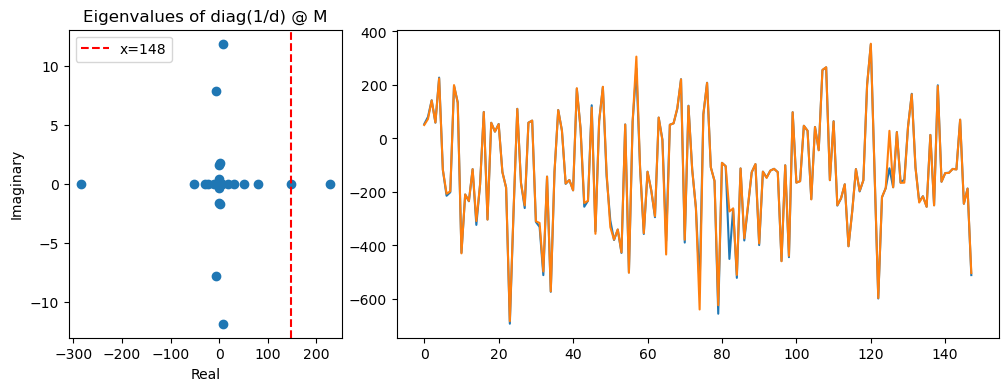

In [18]:
figure(figsize=(12, 4))
d = diag(M)
ee,vv = eig(diag(1/d) @ M)
iord = np.argsort(real(ee))
subplot(1, 3, 1); scatter(real(ee), imag(ee)); xlabel("Real"); ylabel("Imaginary"); title("Eigenvalues of diag(1/d) @ M")
axvline(x=148, color='r', linestyle='--', label='x=148'); legend()
subplot(1, 3, (2,3)); plot(z*148); plot(diag(1/d) @ M @ z)

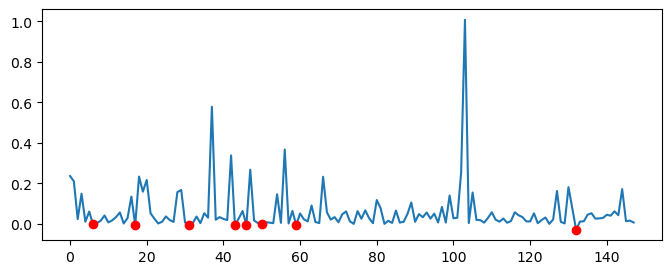

In [26]:
plot(d)
plot(arange(len(d))[d<0], d[d<0], "ro")

Text(0.5, 1.0, 'Eigenvalues of M')

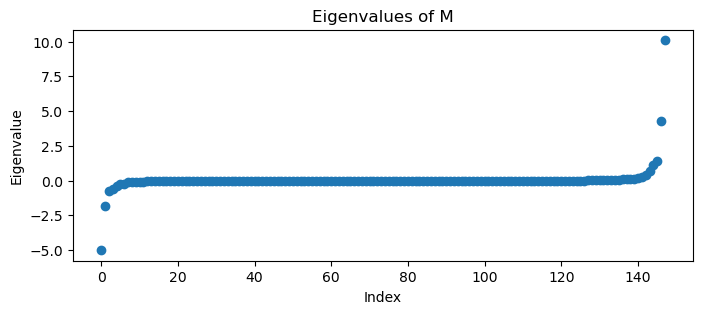

In [27]:
plot(eigvalsh(M), "o")
xlabel("Index"); ylabel("Eigenvalue"); title("Eigenvalues of M")

Text(0.5, 1.0, 'Sorted z values')

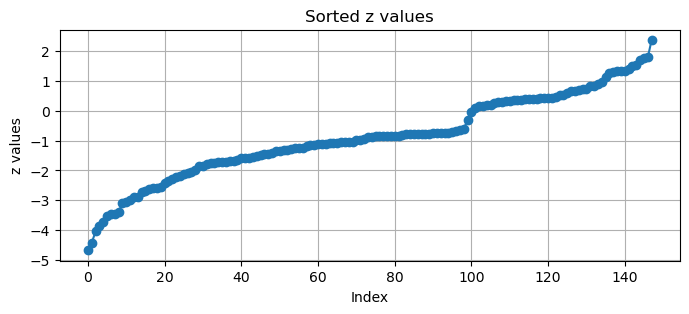

In [28]:
plot(sorted(z), "o-"); grid(True); xlabel("Index"); ylabel("z values"); title("Sorted z values")  

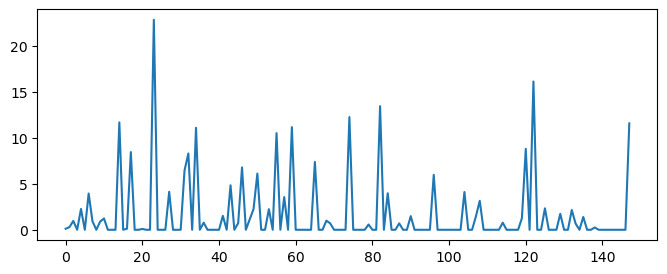

In [29]:
Rij = vstack([outer(X[i], X[j]).flatten() for i in range(X.shape[0]) for j in range(X.shape[0])])
c = C.flatten()
Rii = vstack([outer(X[i], X[i]).flatten() for i in range(X.shape[0])]).T
# Solve Rii w = c for w >=0 
from scipy.optimize import lsq_linear
w = lsq_linear(Rii, c, bounds=(0, np.inf)).x
plot(w)

SignificanceResult(statistic=np.float64(0.4345424728933838), pvalue=np.float64(3.423380349458887e-08))


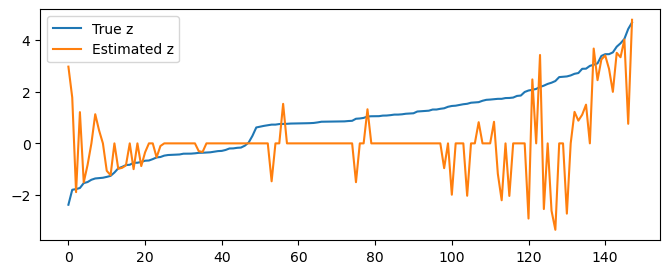

In [32]:
R = X.T @ diag(w) @ X - C
ee, vv = eig(R)
iord = np.argsort(real(ee))
ee = ee[iord]
vv = vv[:, iord]
#plot(ee)
s = sign(X @ vv[:, 0])
#plot(sqrt(w) * s)
#plot(-z)
z1 = sqrt(w) * s
zi = np.argsort(-z)
plot(-z[zi], label = "True z")
plot(z1[zi], label = "Estimated z")
legend()
print(spearmanr(sqrt(w) * s, -z))

### Regressing the gains on signal properties

R^2: 0.4060172397970201
Coefficients: [ 0.4441471  -0.83454793 -0.36560917 -0.01175902]


Text(0.5, 1.0, 'True vs Predicted y values: R^2 = 0.406')

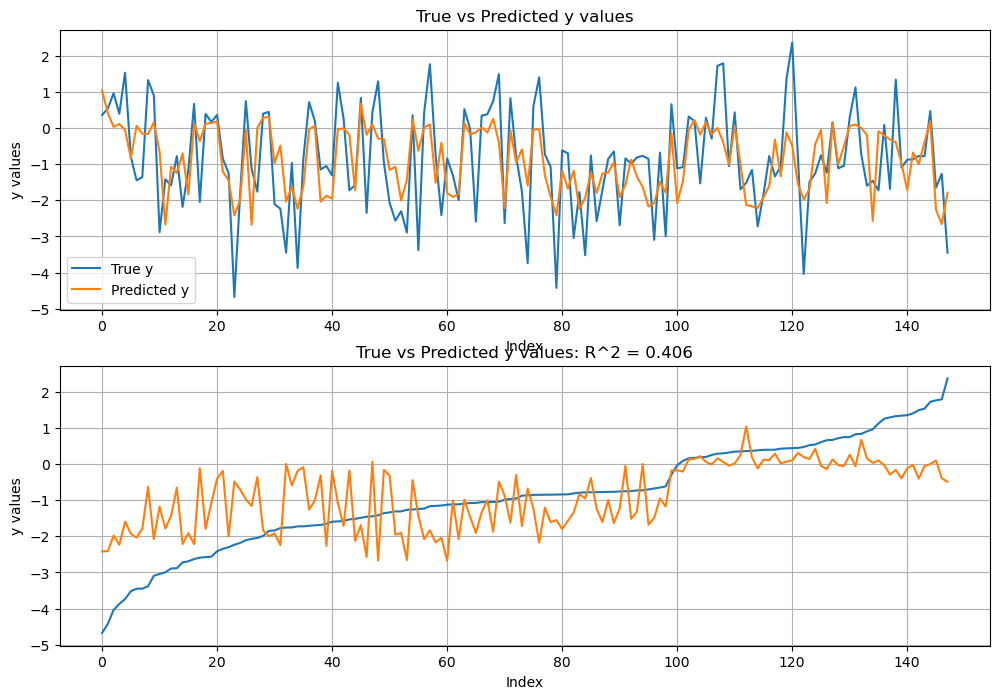

In [33]:
# Regressing z on various metrics
chan_power = diag(X @ X.T)
dem_supp = diag(X @ C @ X.T)/diag(X @ X.T)**2
red = sum((X @ X.T)**2, axis=1) - diag(X @ X.T)**2
mean_al = X @ X.mean(axis=0).T
pred = np.vstack([chan_power, dem_supp, red, mean_al]).T
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
pred = scaler.fit_transform(pred)
y = z
reg = LinearRegression().fit(pred, y)
y_ = reg.predict(pred)
iz = np.argsort(y)
figure(figsize=(12, 8))
subplot(2, 1, 1)
plot(y, label="True y"); plot(y_, label="Predicted y"); legend(); xlabel("Index"); ylabel("y values"); title("True vs Predicted y values"); grid(True)
subplot(2, 1, 2); plot(y[iz], label="True y"); plot(y_[iz], label="Predicted y"); grid(True)
print(f"R^2: {reg.score(pred, y)}")
print(f"Coefficients: {reg.coef_}")
xlabel("Index"); ylabel("y values"); title("True vs Predicted y values: R^2 = {:.3f}".format(reg.score(pred, y)))

### Single element loss function

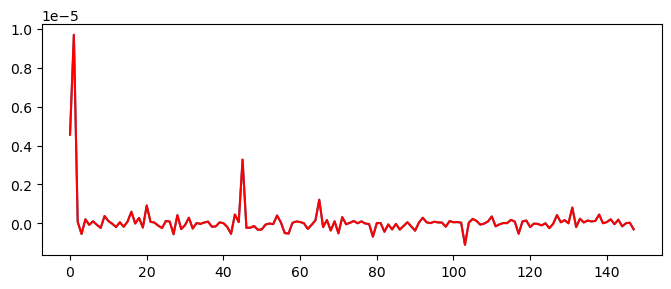

In [149]:
EFUN = lambda z: X.T @ diag(z)@ J @ diag(z) @ X - C
OFF = lambda z, i: z * (1 -  np.eye(len(z))[i])
MFUNi = lambda i: X.T @ OFF(z,i)
EFUNi = lambda i: EFUN(OFF(z, i))
ch_pow = diag(X @ X.T)
N = X.shape[0]
m2= np.array([sum(MFUNi(i)**2) for i in range(N)])
p = np.array([dot(X[i], MFUNi(i)) for i in range(N)])
q = np.array([dot(X[i], EFUNi(i) @ X[i].T) for i in range(N)])
t = np.array([dot(X[i], EFUNi(i) @ MFUNi(i)) for i in range(N)])
al= (N-1)/N
k = al * q + 1/N**2*(ch_pow * m2 + p**2)

coefs = np.array([
    2 * al**2 * ch_pow **2,
    -6 * al * ch_pow * p/N,
    2 * k,
    -2 * t /N
])

zz = np.array([z**3 , z**2, z, np.ones_like(z)])
g_z = np.sum(coefs * zz, axis=0)
plot(g_z/48/48)
plot(mdl.JAC_LOSS(z), "r")
#plot(mdl.JAC_LOSS(z)*2000)

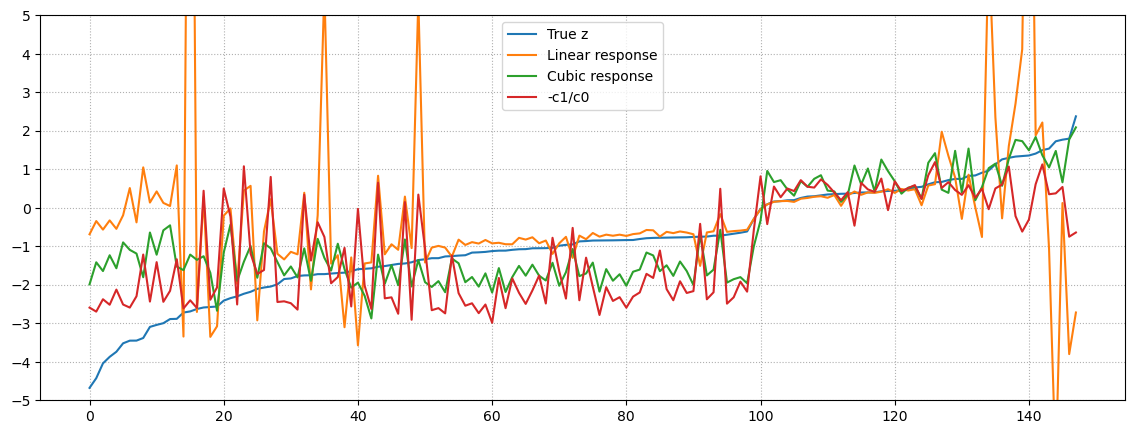

In [35]:
figure(figsize=(14, 5))
ii = argsort(z)
z_small = (t/N/k)
z_large = (np.abs(t)/N/al**2/ch_pow**2)**(1/3) * sign(z) 
z_large2 = -coefs[1]/coefs[0]
z_exact = np.array([np.roots(c) for c in coefs.T])
plot(z[ii], label="True z")
plot(z_small[ii], label="Linear response")
plot(z_large[ii], label="Cubic response")
plot(z_large2[ii], label="-c1/c0")
grid(True, linestyle=":")
legend()    
ylim([-5,3])
gca().set_yticks(arange(-5,6));

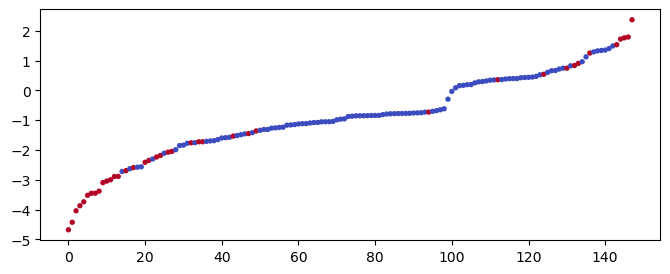

In [420]:
plt.scatter(np.arange(N), z[ii], c=(k[ii]<0), cmap='coolwarm', s=8)

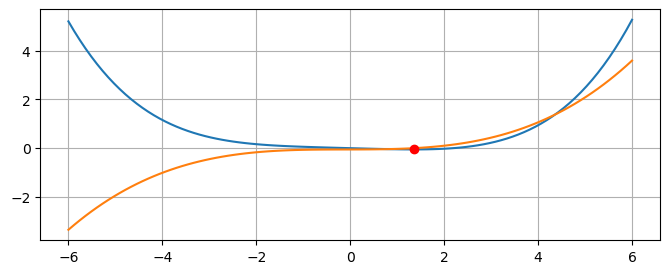

In [87]:
LFUN = lambda z, i: dot(np.array([z**4, z**3, z**2, z**1]), np.diag([1/4, 1/3, 1/2, 1]) @ coefs[:, i])
GFUN = lambda z, i: dot(np.array([z**3, z**2, z**1, z**0]), coefs[:, i])
zvals = linspace(-6,6,100)
j = 140
lvals = np.array([LFUN(zi, ii[j]) for zi in zvals])
gvals = np.array([GFUN(zi, ii[j]) for zi in zvals])
plot(zvals, lvals)
plot(zvals, gvals)
grid(True)
plot(z[ii[j]], LFUN(z[ii[j]], ii[j]), "ro")

#### Check small-large boundary

(-5.0, 5.0)

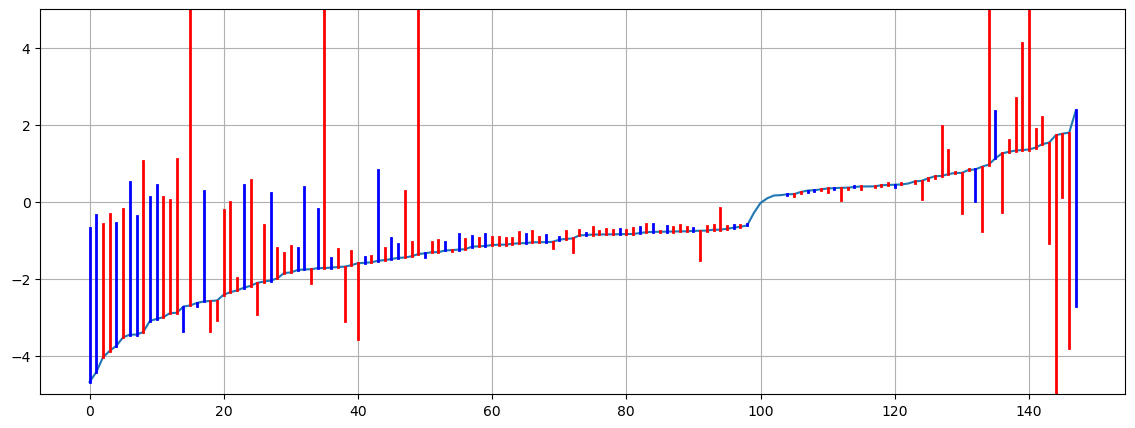

In [74]:
figure(figsize=(14,5))
assert allclose(z_small, -coefs[-1]/coefs[-2])
g1vals = np.array([GFUN(zi, ii[j]) for zi in z])
ii = argsort(z)
plot(z[ii])
#twinx()
#plot(abs(g1vals[ii]/coefs[-1][ii]),"r")
crit= g1vals/coefs[-1]
k_crit = 3 * p**2/len(z)**2
#mask = abs(crit) < 1
mask = k < k_crit
# Plot vertical bars from z to z_small
# Color them by whether abs(crit) < 1
xx = np.arange(N)
yy = np.array([z_small[ii], z[ii]])
plot([xx[mask], xx[mask]], yy[:, mask], color="b", alpha=1, lw=2);
plot([xx[~mask], xx[~mask]], yy[:, ~mask], color="r", alpha=1, lw=2);
grid(True)
ylim(-5,5)

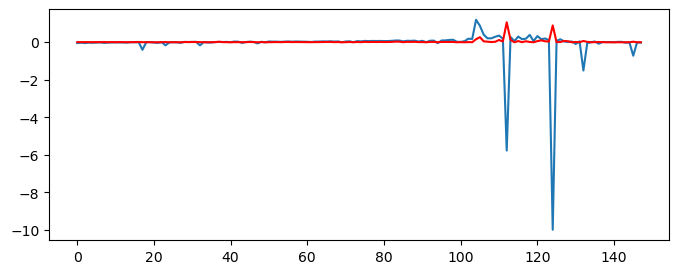

In [ ]:
plot(k[ii])
plot(k_crit[ii], "r")


### Various Approximations

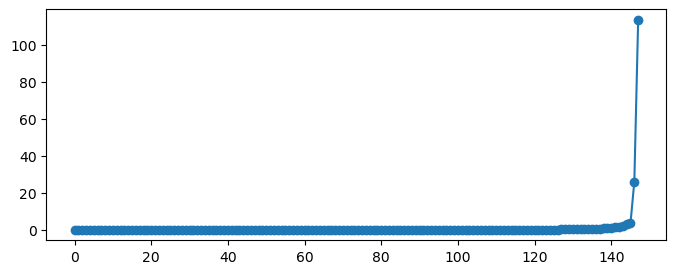

In [24]:
ee = eigvalsh(Rii.T @ Rii)
plot(ee, "o-")

In [271]:
# Rii w = c
# Rii' Rii w = Rii' c
# w = np.linalg.solve(Rii.T @ Rii, Rii.T @ c)
G = Rii.T @ Rii
g = Rii.T @ c
w_ls = np.linalg.solve(G, g)

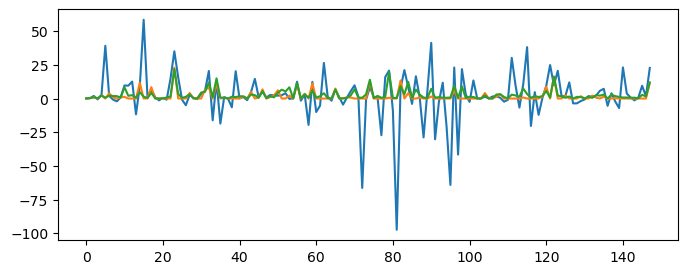

In [274]:
plot(w_ls)
plot(w)
plot(z**2)

In [237]:
def loss(z):
    Y_ = diag(z) @ X
    C_ = Y_.T @ J @ Y_
    return norm(C_ - C, "fro")**2

res = minimize(loss, z, method="L-BFGS-B", options = {"maxfun":10000})
res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 59.2421152568165
        x: [ 3.627e-01  5.437e-01 ... -1.267e+00 -3.455e+00]
      nit: 38
      jac: [-4.093e-04  1.187e-04 ...  2.842e-06  2.274e-05]
     nfev: 6854
     njev: 46
 hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>

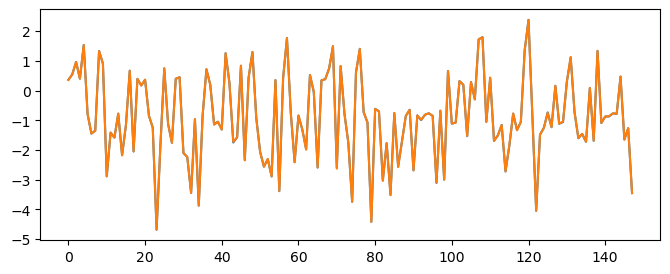

In [238]:
plot(res.x)
plot(z)

In [232]:
def loss_zb(p):
    z = p[:-48]
    b = p[-48:]
    Y_ = diag(z) @ X
    C_ = Y_.T @ Y_
    E = C_ - outer(b, b) - C
    return np.sum(E**2)

def loss_no_center(z):
    Y_ = diag(z) @ X
    C_ = Y_.T @ Y_
    E = C_ - C
    return np.sum(E**2)

def loss_full(z):
    Y_ = diag(z) @ X
    C_ = Y_.T @ J @ Y_
    E = C_ - C
    return np.sum(E**2)

from scipy.optimize import minimize
res_zb = minimize(loss_zb, np.random.rand(X.shape[0] + 48), method ="L-BFGS-B", options={"maxfun": 100000, "gtol":1e-6, "disp": True})

In [230]:
res_no_center = minimize(loss_no_center, np.random.rand(X.shape[0]), method ="L-BFGS-B", options={"maxfun": 100000, "gtol":1e-6, "disp": True}) 

In [239]:
res_full = minimize(loss_full, np.random.rand(X.shape[0]), method ="L-BFGS-B", options={"maxfun": 100000, "gtol":1e-6, "disp": True})

In [240]:
res_full

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 60.38978382384035
        x: [-3.895e-01  4.598e-01 ...  1.177e+00  3.111e+00]
      nit: 333
      jac: [ 5.535e-04 -3.183e-04 ... -1.563e-05  1.847e-05]
     nfev: 56173
     njev: 377
 hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>

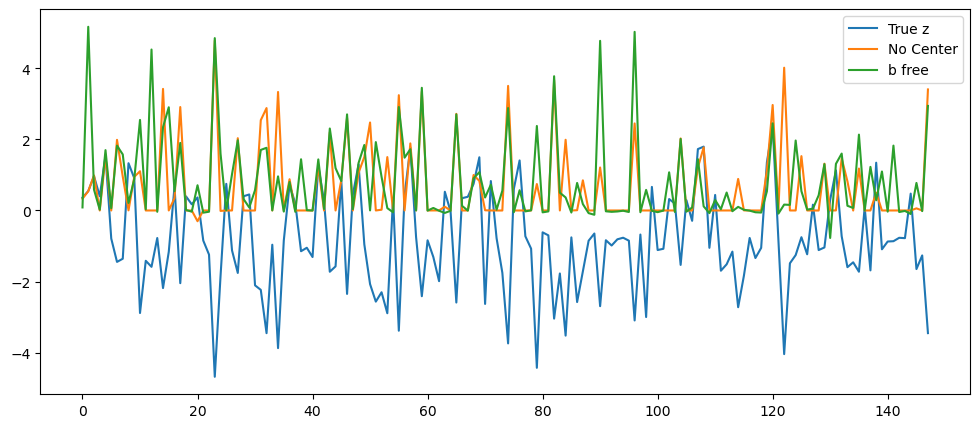

In [249]:
figure(figsize=(12,5))
plot(z, label="True z")
plot(res_no_center.x, label="No Center")
plot(res_zb.x[:-48], label="b free")
legend()


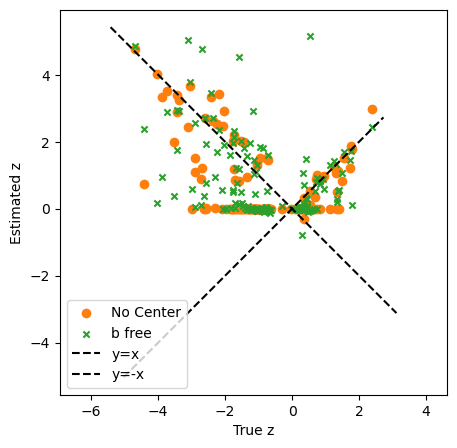

In [260]:
figure(figsize=(5,5))
scatter(z, res_no_center.x, c = "C1", label="No Center")
scatter(z, res_zb.x[:-48], marker="x", s=20, c="C2", label="b free")
plot(xlim(), xlim(), "k--", label="y=x")
plot(xlim(), -np.array(xlim()), "k--", label="y=-x")
axis("equal")
xlabel("True z"); ylabel("Estimated z")
legend(loc="lower left")

Text(0.5, 1.0, 'Estimated w and True z^2')

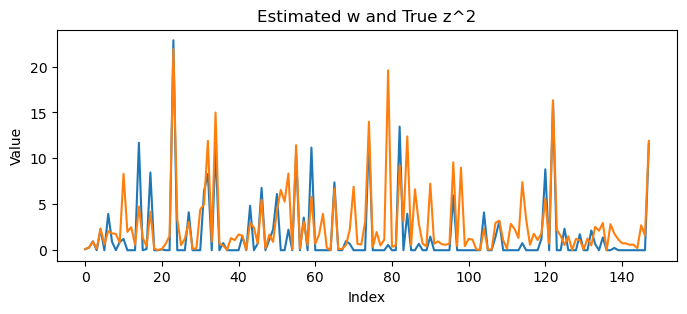

In [264]:
plot(w)
plot(z**2)
xlabel("Index"); ylabel("Value"); title("Estimated w and True z^2")


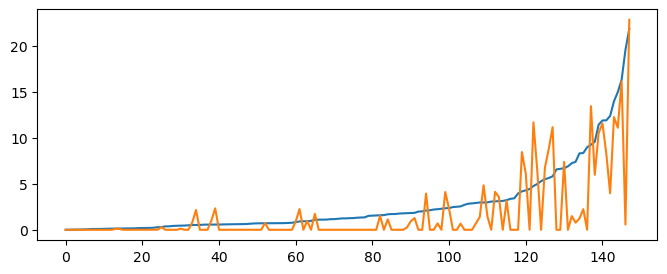

In [265]:
iord = np.argsort(z**2)
plot(z[iord]**2)
plot(w[iord])

In [269]:
mdl.COV_LOSS(z), loss_no_center(res_no_center.x)/48**2/2, loss_zb(res_zb.x)/2/48**2, mdl.COV_LOSS(res_full.x)

(np.float64(0.012856446069585756),
 np.float64(0.013754204455380151),
 np.float64(0.010239686356780683),
 np.float64(0.013105421836770909))

In [228]:
from scipy.stats import spearmanr, pearsonr
pearsonr(w, z**2), spearmanr(w, z**2)

(PearsonRResult(statistic=np.float64(0.7464004020315655), pvalue=np.float64(1.3276677340217189e-27)),
 SignificanceResult(statistic=np.float64(0.6349074728748747), pvalue=np.float64(4.4924531549642195e-18)))

### Quartic analysis

In [266]:
class Quartic:
    @staticmethod
    def OFF(z, i):
        z = z.copy()
        z[i] = 0
        return z

    def __init__(self, X, C, z, la):
        self.X, self.C, self.z, self.la = X, C, z, la 
        self.N, self.n_od = X.shape
        self.al= (self.N - 1)/self.N
        self.m = self.X.T @ self.z
        self.E = self.EFUN(z)
        self.build_vars()

    def build_vars(self):
        self.x2_= np.sum(self.X**2,axis=1)
        self.m_ = np.array([self.MiFUN(i) for i in range(self.N)]) 
        Ei      = [self.EiFUN(i) for i in range(self.N)]
        self.p_ = np.array([Xi @ m_i       for Xi, m_i      in zip(self.X, self.m_)])
        self.q_ = np.array([Xi @ E_i @ Xi  for Xi, E_i      in zip(self.X, Ei)])
        self.t_ = np.array([Xi @ E_i @ m_i for Xi, E_i, m_i in zip(self.X, Ei, self.m_)])
        self.m2_= np.sum(self.m_**2, axis=1)
        self.k_ = self.al * self.q_ + (self.x2_ * self.m2_ + self.p_**2)/self.N**2

        self.A_ = 1/2*self.al**2  * self.x2_**2
        self.B_ =-2*self.al/self.N * self.x2_ * self.p_ 
        self.C_ = self.k_ + self.la/2
        self.D_ =-(2 * self.t_/self.N  + self.la)

        self.b_ =  self.B_/self.A_
        self.c_ =  self.C_/self.A_
        self.d_ =  self.D_/self.A_
        self._c = -self.b_ / 4
        self._p =  self.c_ - 3/8*self.b_**2
        self._q =  self.d_ - self.b_ * self.c_/2 + self.b_**3/8

        self.LiFUN = lambda i, z: self.A_[i] * z**4 + self.B_[i]* z**3 + self.C_[i]*z**2 + self.D_[i]*z
        self.Li1FUN= lambda i, z: 4 * self.A_[i] * z**3 + 3 * self.B_[i] * z**2 + 2 * self.C_[i]*z + self.D_[i] 

    def EFUN(self, z):
        return self.MFUN(z) - self.C
    
    def EiFUN(self, i):
        return self.EFUN(self.OFF(self.z,i))

    def MFUN(self, z):
        m = self.X.T @ z
        return self.X.T @ np.diag(z**2) @ self.X - np.outer(m, m)/self.N

    def MiFUN(self, i):
        return self.m - self.z[i] * self.X[i]

    def wells(self, i):
        """Real minima in gain units, and whether they straddle zero."""
        r = np.roots([4*self.A_[i], 3*self.B_[i], 2*self.C_[i], self.D_[i]])
        r = np.real(r[np.abs(np.imag(r)) < 1e-9])
        mins = r[12*self.A_[i]*r**2 + 6*self.B_[i]*r + 2*self.C_[i] > 0]
        return mins, (len(mins) > 1 and mins.min()*mins.max() < 0)

    def escapes(self):
        out = []
        for i in range(self.N):
            mins, straddle = self.wells(i)
            if straddle:
                best = mins[np.argmin(self.LiFUN(i, mins))]
                if abs(best - self.z[i]) > 1e-6:
                    out.append((i, self.z[i], best, self.LiFUN(i, best) - self.LiFUN(i, self.z[i])))
        return out
       

In [277]:
L_true = 0.5*np.sum(Q.EFUN(Q.z)**2) + 0.5*Q.la*np.sum((Q.z-1)**2)
print(L_true, mdl.COV_LOSS(z), L_true/mdl.COV_LOSS(z))   # expect ~2304

29.803257170379393 0.013198723454747097 2258.0408834659124


In [ ]:

mdl.COV_LOSS(z)

np.float64(0.013198723454747097)

In [311]:
import conn_models; reload(conn_models)
from conn_models import common as models_common; reload(models_common)
from conn_models import diag as diag_model; reload(diag_model)
reload(driver)

<module 'driver' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/model-fitting/driver.py'>

In [347]:
ex_inp["min_args"]["options"]

{'ftol': 1e-08, 'gtol': 1e-07, 'maxfun': 1000}

In [350]:
model = trials.model("Diag")
df = model.df
la_vals = sorted(df.λ.unique()) 
which_la = 1e-4
ex = model.extract(seed=0, train=0, la=which_la, metric="r2", with_params=True)
z = ex.params["p_final"]
ex_in_file = os.path.join(model.base_dir, ex.params["file"].replace("out", "in"))
with open(ex_in_file, "rb") as f:
    ex_inp = pickle.load(f)
ex_inp["sampler"]["n_train"] = 10
ex_inp["min_args"]["options"]["gtol"]= 1e-8
res, dataset, mdl = driver.run(ex_inp, return_dataset=True, return_model=True)

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(0.0001)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
Running minimization with 2

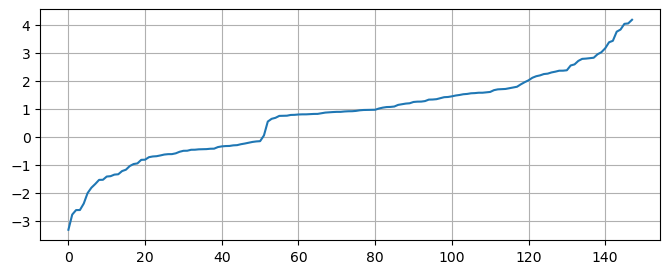

In [355]:
plot(sorted(mdl.r)); grid(True); gca().set_yticks(arange(-3, 5, 1))

In [356]:
X, Y = dataset["XX"].trains[0], dataset["YY"].trains[0]
Q = Quartic(X, mdl.Cstars[0], mdl.r, which_la)
esc = np.array(Q.escapes())

In [363]:
ii = np.argsort(Q.z)
which_ii = -1; 
which_i = ii[which_ii]

Text(0.5, 1.0, 'Loss function for sorted index -1')

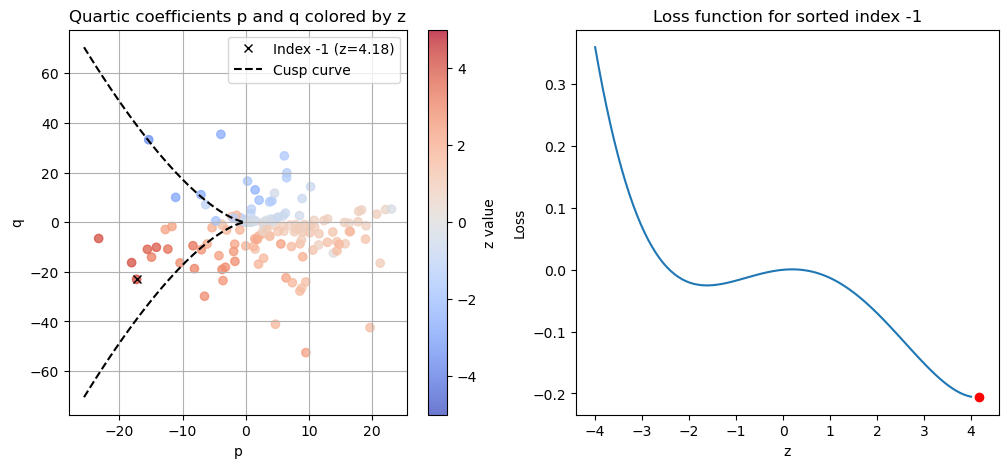

In [366]:
figure(figsize=(12,5))
subplot(1,2,1)
color_by = {"z":(Q.z, -5, 5),
            "k":(Q.k_, -0.25, 0.25),}["z"]
scatter(Q._p, Q._q, c = color_by[0], alpha=0.75, cmap="coolwarm", vmin=color_by[1], vmax=color_by[2])
grid(True)
#scatter(Q._p, Q._q, c = Q._c, cmap="rainbow")
plot(Q._p[which_i], Q._q[which_i], "kx", label=f"Index {which_ii} (z={Q.z[which_i]:.2f})")
xlabel("p"); ylabel("q"); title("Quartic coefficients p and q colored by z")
colorbar(label="z value")
pvals = np.linspace(min(xlim()), 0, 100)
# Plot the cusp curve: 27 q^2 = 8 (-p)^3
cusp_q = np.sqrt(8/27 * (-pvals)**3)
plot(pvals, cusp_q, "k--", label="Cusp curve"); plot(pvals, -cusp_q, "k--"); legend()
subplot(1,2,2)
# Plot the loss function for the given index
zvals = np.linspace(-4,4,100)
plot(zvals, Q.LiFUN(which_i, zvals), label=f"Loss function for index {which_i} (z={Q.z[which_i]:.2f})")
plot(Q.z[which_i], Q.LiFUN(which_i, Q.z[which_i]), "ro", label="True z")
xlabel("z"); ylabel("Loss"); title(f"Loss function for sorted index {which_ii}")

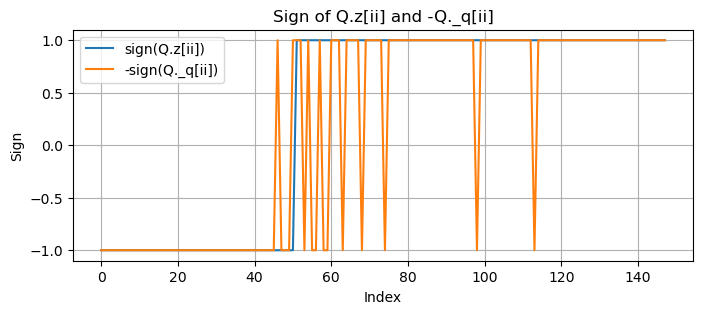

In [371]:
plot(sign(Q.z[ii]), label="sign(Q.z[ii])")
plot(-sign(Q._q[ii]), label="-sign(Q._q[ii])")
xlabel("Index"); ylabel("Sign"); title("Sign of Q.z[ii] and -Q._q[ii]"); grid(True);
legend()

(np.float64(-3.696041836934124),
 np.float64(4.554332964200052),
 np.float64(-0.4760825166084683),
 np.float64(1.0758218073190735))

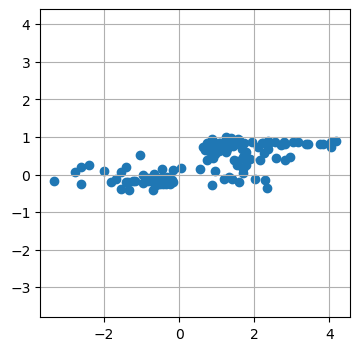

In [377]:
figure(figsize=(4,4))
scatter(Q.z, Q._c);
grid(True)
axis("equal")

In [380]:
z_approx= Q._c + sign(-Q._q) * np.sqrt(np.maximum(0, -Q._p/2))

np.float64(0.8665267196422566)

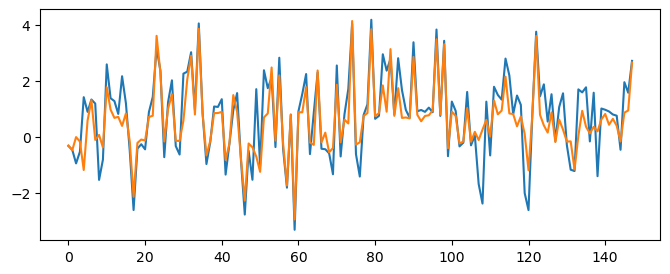

In [385]:
plot(Q.z)
plot(z_approx)
corrcoef(Q.z, z_approx)[0,1]

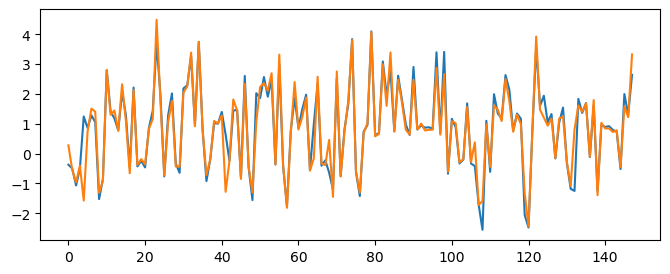

In [183]:
plot(z)
plot(mdl.r)

In [172]:
ex.params["file"]

'out.8.p'

## Compare Diag and DiagInh
These two models seem to give very similar performance on covariance, but quite different in terms of correlation. Let's understand why.

In [44]:
import layout; reload(layout)
import results; reload(results)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
split = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


In [45]:
from matplotlib.gridspec import GridSpec
def plot_comparison(models):
    n_mods = len(models)
    model_names = models.keys()
    fig = plt.figure(figsize=(4 * (2 + n_mods + 2), 8))
    gs = GridSpec(2, 2 + n_mods + 2)
    records = [] 
    ax_params = fig.add_subplot(gs[0,-3:])
    ax_hist = fig.add_subplot(gs[1,-3:])
    ax_cstar = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0])]
    for i, (name, m) in enumerate(models.items()):
        ax = [fig.add_subplot(gs[0, i+1]), fig.add_subplot(gs[1, i+1])]
        if i == 0:
            # In the first row, do a matshow of Cstar, then of Cest (on the same scale), then a scatter plot of Cstar vs Cest
            vmin, vmax = percentile(m.vld.Cstar, [1, 99])
            ax_cstar[0].matshow(m.vld.Cstar, vmin=vmin, vmax=vmax, cmap="Spectral_r")
            ax_cstar[0].set_title("Cstar")
            ax_cstar[1].matshow(m.vld_corrs["Cstar"], vmin=0, vmax=1, cmap="bwr")
            ax_cstar[1].set_title("Rstar")
        
        ax[0].matshow(m.vld.Cest, vmin=vmin, vmax=vmax, cmap="Spectral_r")
        ax[0].set_title(f"Cest ({name})") 
        ratio = np.mean((m.vld.Cest - m.vld.Cstar)**2) / np.mean((m.vld.Cin - m.vld.Cstar)**2)
    
        ax[1].matshow(m.vld_corrs["Cest"], vmin=0, vmax=1, cmap="bwr")
        ax[1].set_title(f"Rest ({name})")

        ax_params.plot(m.params["p_final"], label=name, color=pfm.model_color(name))    
        ax_params.set_title("Final Parameters")
        ch = m.params["history"]["cov"] 
        ax_hist.semilogy(m.params["history"]["it"], ch, label=f"{name} (la = {m.la:1.1e}): {ch[-1]:.1f}", color=pfm.model_color(name))
        ax_hist.set_title("Covariance History")
        print(f"{name}: ")
        print(m.params["mdl.results"])

        corr_energy = compute_corr_energ_(m.vld_corrs["Cest"])
        records.append({"name": name, "ratio": ratio, "corr_energy": corr_energy})
    ax_params.legend()
    ax_hist.legend()

    return pd.DataFrame(records)

Diag: 
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.013073917035798372
        x: [ 1.948e-01  4.570e-01 ... -8.368e-01 -5.136e-01]
      nit: 98
      jac: [-1.206e-07 -9.604e-06 ...  5.786e-08 -2.103e-08]
     nfev: 106
     njev: 106
 hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>
DiagOnlyInh: 
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.013130046447425147
        x: [ 2.036e-01  4.553e-01 ... -9.573e-01 -5.016e-01]
      nit: 96
      jac: [-3.991e-06 -3.929e-06 ... -1.367e-07 -6.962e-08]
     nfev: 101
     njev: 101
 hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>


,name,ratio,corr_energy
0,Diag,0.220008,0.107050
1,DiagOnlyInh,0.218160,0.109295


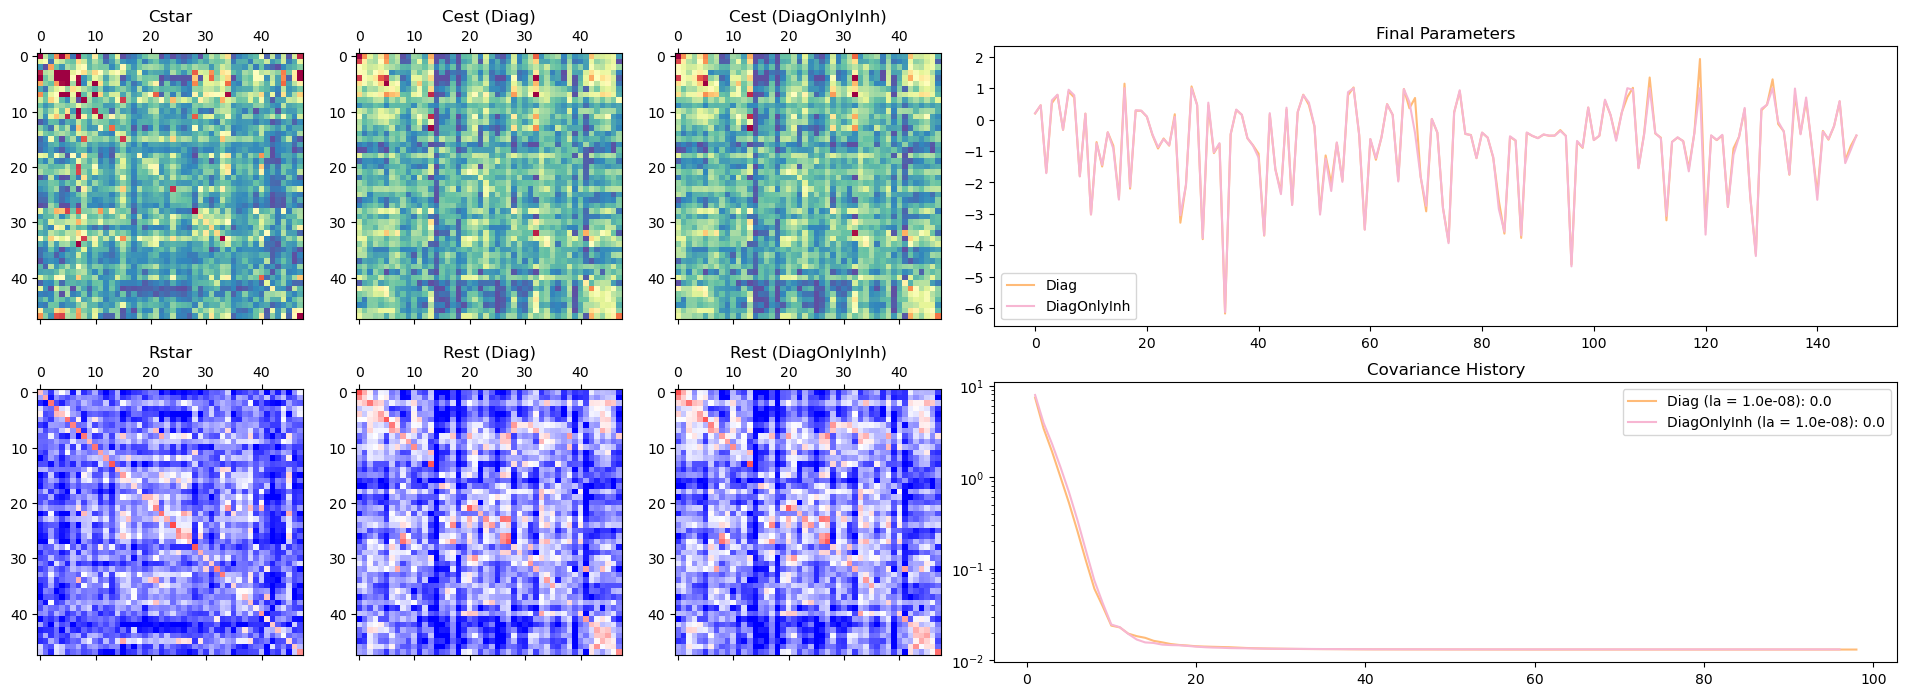

In [46]:
seed = 9
selection_metric = "ratio"
m_diag = split.model("Diag").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params = True)
m_diag_inh = split.model("DiagOnlyInh").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params=True)
plot_comparison({"Diag": m_diag, "DiagOnlyInh": m_diag_inh})

In [47]:
covs, corr_ens = [], []
covs_inh, corr_ens_inh = [], []
pfinals, pfinals_inh = [], []
for seed in range(50):
    res = split.model("DiagOnlyInh").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params=True)
    covs_inh.append(res.params["history"]["cov"][-1])
    corr_ens_inh.append(compute_corr_energ_(res.vld_corrs["Cest"]))
    pfinals_inh.append(res.params["p_final"])
    res = split.model("Diag").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params=True)
    covs.append(res.params["history"]["cov"][-1])
    corr_ens.append(compute_corr_energ_(res.vld_corrs["Cest"]))
    pfinals.append(res.params["p_final"])
pfinals = np.array(pfinals)
pfinals_inh = np.array(pfinals_inh)

Text(0.5, 1.0, 'Final Correlation Energy')

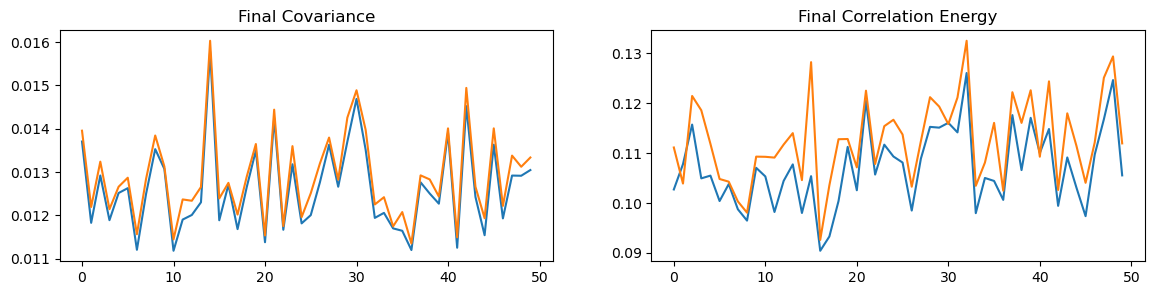

In [48]:
fig,ax = subplots(nrows=1, ncols=2, figsize=(14, 3))
ax[0].plot(covs); ax[0].plot(covs_inh); ax[0].set_title("Final Covariance")
ax[1].plot(corr_ens); ax[1].plot(corr_ens_inh); ax[1].set_title("Final Correlation Energy")

### Compare solutions

In [49]:
def plot_pfinals(pfinals, covs):
    u,s,v = np.linalg.svd(pfinals, full_matrices=False)
    c = u @ np.diag(s)
    iord = np.argsort(c[:,0]).astype(int)
    fig, ax = plt.subplots(figsize=(14,5))
    ax.matshow(pfinals[iord,:], vmin=-5, vmax=5, cmap="bwr")
    ax.set_yticks(np.arange(len(iord)), labels=iord, fontsize=6);
    ax.set_xlabel("Input Channel")
    ax1 = ax.twiny()
    ax1.plot(np.array(covs)[iord], np.arange(len(iord)), '-')
    ax1.set_xlabel("Final Covariance")
    return fig, ax, ax1, c[:,0]

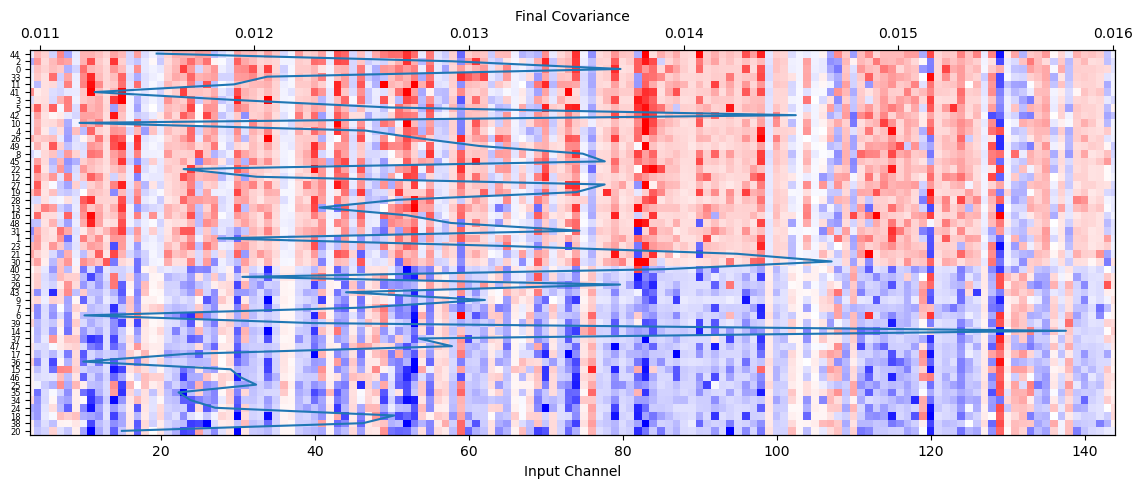

In [50]:
fig, ax, xa1, c = plot_pfinals(pfinals, covs) 

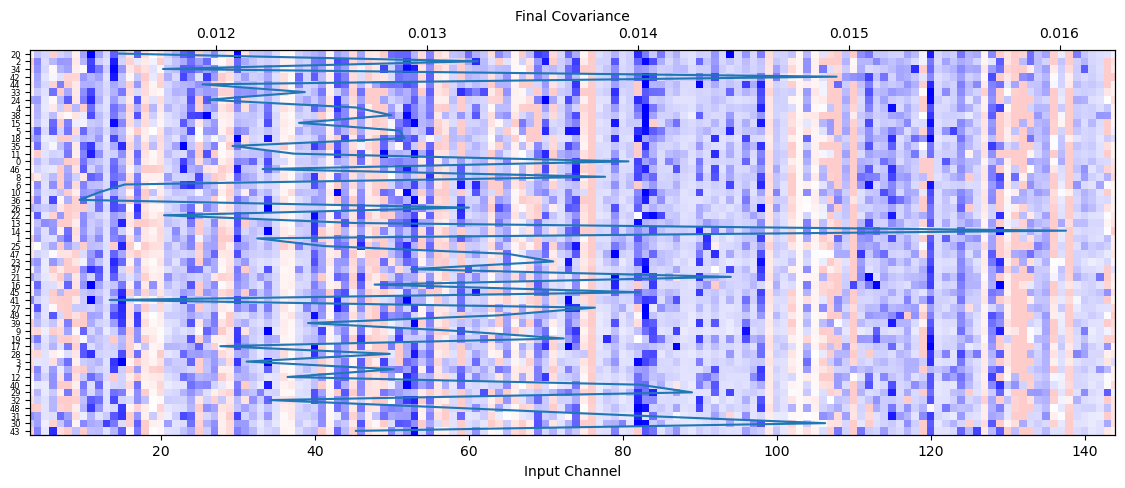

In [51]:
fig, ax, ax1, c = plot_pfinals(pfinals_inh, covs_inh)

### Let's run seed 9 manually
Perhaps poor results were due to (too) early exit.

In [52]:
trials = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


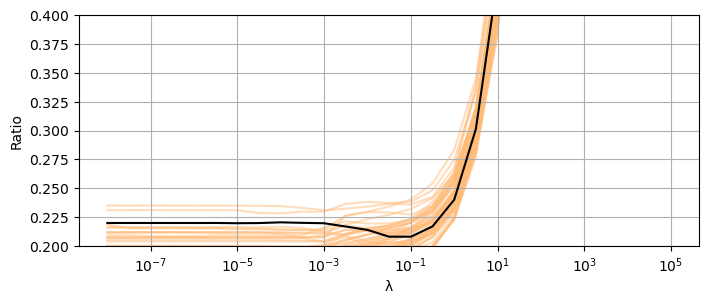

In [53]:
# Plot the test ratio for seeds
mdl = "DiagOnlyInh"
mdl = "Diag"
df = trials.loaded_models[mdl]["df"]
seeds = df["seed"].unique()
for i in sorted(seeds):
    df_sub = df[(df.seed == i) & (df.split=="vld") & (df.ref=="train[0]")].sort_values("λ")
    la = df_sub["λ"]
    ratio = df_sub["ratio"]
    semilogx(la, ratio, '-', color=pfm.model_color(mdl) if i != 9 else "k", alpha=0.5 if i != 9 else 1, label=f"seed {i}", zorder=1 if i != 9 else 2)
xlabel("λ")
ylabel("Ratio")
ylim(0.2,0.4)
grid(True)


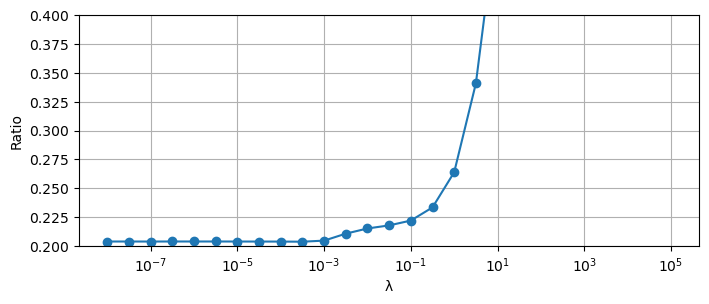

In [54]:
df_sub = df_sub.sort_values("λ")
la = df_sub["λ"]
rato = df_sub["ratio"]
semilogx(la, rato, 'o-')
ylim(0.2,0.4)
xlabel("λ")
ylabel("Ratio")
grid(True)

In [55]:
# Manually run in.225.p
in_file = os.path.join(trials.split_dir, "fit_diag", "in.0.p")
print(f"Loading input file: {in_file}")
with open(in_file, "rb") as f:
    inp = pickle.load(f)
inp["sampler"]["n_train"]=1
results, dataset, mdl = driver.run(inp, return_dataset=True, return_model=True)

Loading input file: /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/fit_diag/in.0.p
Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=1, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=1, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing traini

In [56]:
from conn_models.common import compute_ratio

In [57]:
results["mdl.results"]

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.012856473565028793
        x: [ 3.630e-01  5.442e-01 ... -1.264e+00 -3.450e+00]
      nit: 175
      jac: [ 4.564e-06  9.704e-06 ...  2.565e-08 -3.158e-07]
     nfev: 197
     njev: 197
 hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>

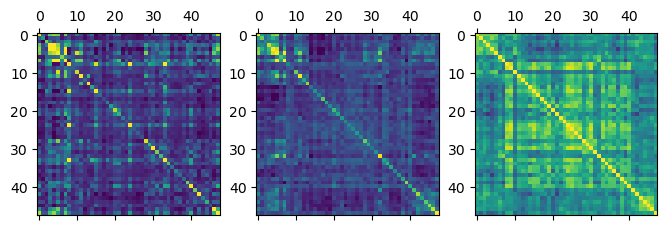

In [58]:
r = results["split"].trains[0]
fig, ax = plt.subplots(1, 3, figsize=(8, 3))
vlim = np.percentile(r.Cstar, [1, 99])
[axi.matshow(C, vmin=vlim[0], vmax=vlim[1]) for axi, C in zip(ax, [r.Cstar, r.Cest, r.Cin])]

# Free Model

In [29]:
sys.path.append(os.path.join(git_path))
from label_axes.label_axes import label_axes
# Get row and col order of given W by hierarchical clustering of the rows and columns of W
from scipy.cluster.hierarchy import linkage, leaves_list
def get_row_col_order(W, method='ward'):
    # Compute the linkage for rows and columns
    row_linkage = linkage(W, method=method)
    col_linkage = linkage(W.T, method=method)

    # Get the order of rows and columns based on the clustering
    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)

    return row_order, col_order

In [30]:
import conn_models; reload(conn_models); from conn_models import free as free_model
reload(free_model); from conn_models import free_lat as free_lat_model; reload(free_lat_model)

<module 'conn_models.free_lat' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/model-fitting/conn_models/free_lat.py'>

Free: 
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 362.68287357308316
        x: [ 6.091e-01 -4.297e-03 ... -2.464e-03  9.998e-01]
      nit: 84
      jac: [-5.079e-02 -7.047e-02 ... -8.877e-04 -5.639e-04]
     nfev: 90
     njev: 90
 hess_inv: <21904x21904 LbfgsInvHessProduct with dtype=float64>
FreeLat: 
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 383.5485055258314
        x: [ 3.879e+00  3.445e-01 ... -7.830e-02  3.246e-02]
      nit: 771
      jac: [ 5.569e-02 -3.331e-03 ...  5.687e-03  2.068e-03]
     nfev: 821
     njev: 821
 hess_inv: <21756x21756 LbfgsInvHessProduct with dtype=float64>


,name,ratio,corr_energy
0,Free,0.232419,0.135143
1,FreeLat,0.231126,0.137251


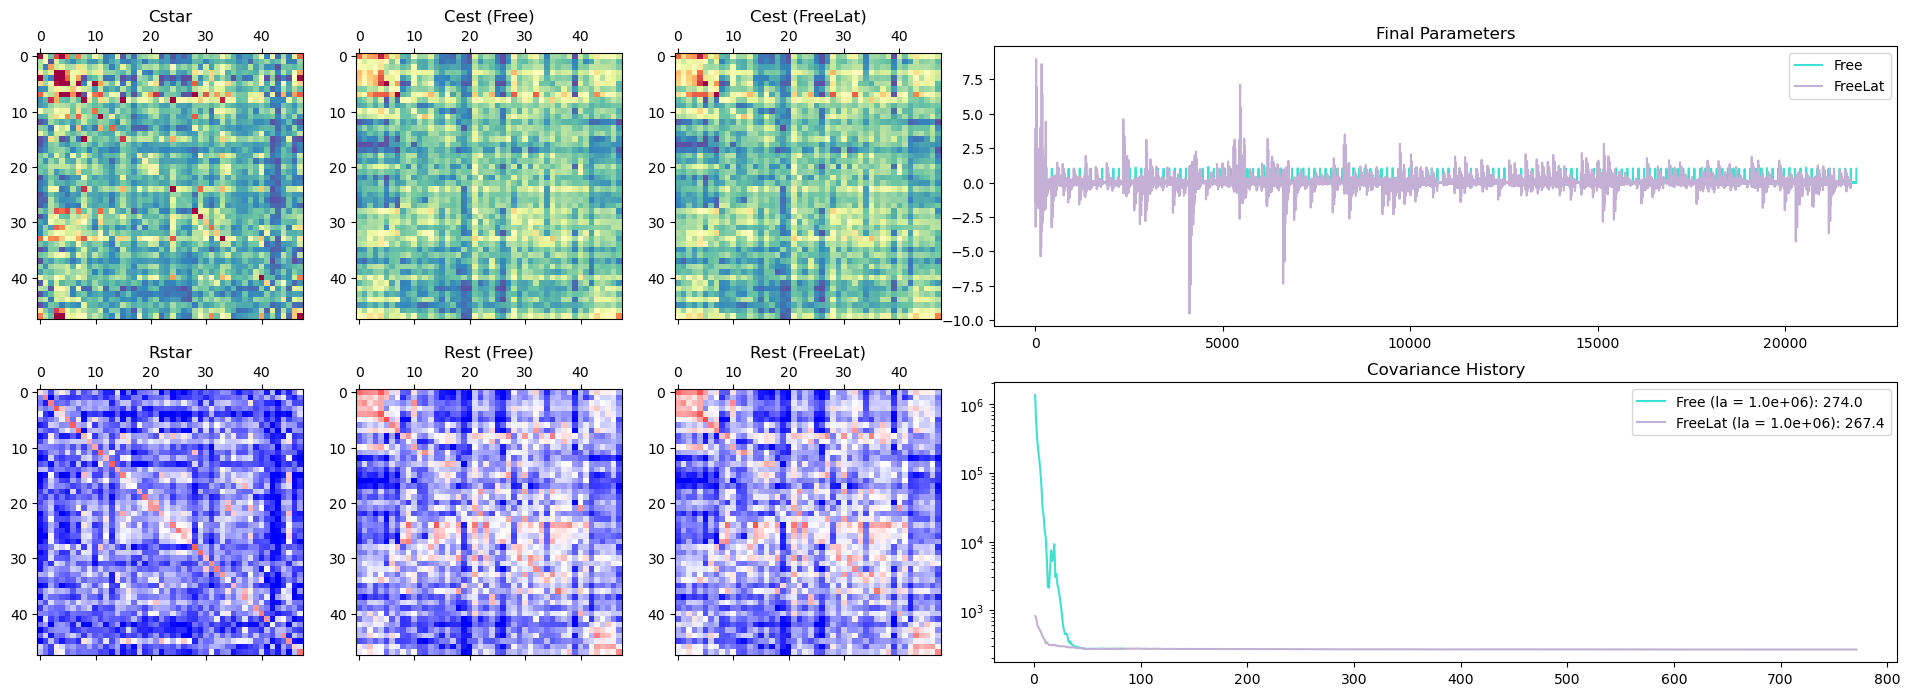

In [121]:
seed = 27
selection_metric = "r2"
m_free = split.model("Free").extract(seed=seed, train=0, la = None, metric=selection_metric, with_params = True)
m_free_lat = split.model("FreeLat").extract(seed=seed, train=0, la = None, metric=selection_metric, with_params=True)
plot_comparison({"Free": m_free, "FreeLat": m_free_lat})

In [122]:
Zfree = free_model.Model._ZFUN(m_free.params["p_final"])
Wfree = np.linalg.inv(Zfree) - np.eye(Zfree.shape[0])
Wlat = free_lat_model.Model._WFUN(m_free_lat.params["p_final"])
m = Wlat.shape[0]; Zlat = np.linalg.inv(np.eye(m) + Wlat)

(A) The estimated solutions are very similar.

(B) The effective feedforward solutions $Z$ are similar.

(C) The effective recufrrent solutions $W$ are different


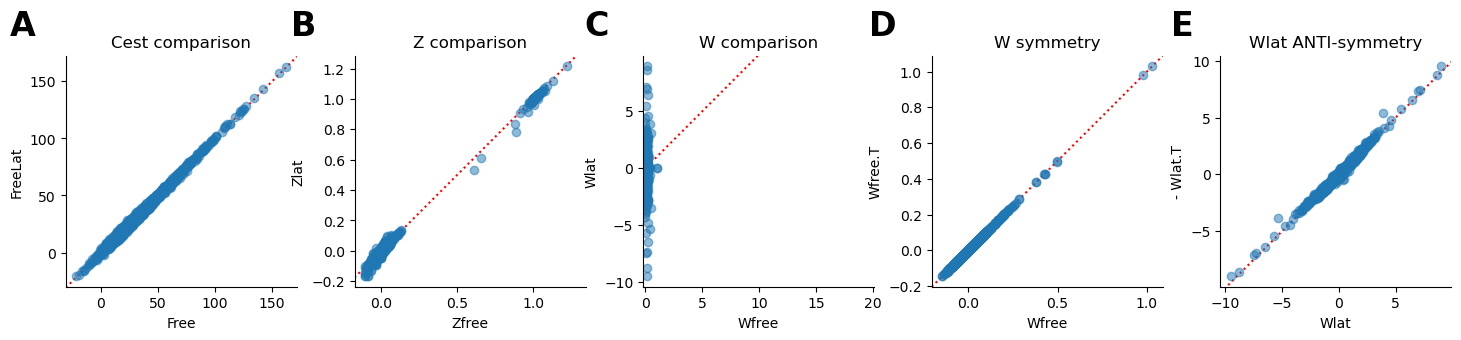

In [123]:
fig, ax = subplots(nrows=1, ncols=5, figsize=(18, 3))
ax[0].plot(m_free.vld.Cest.flatten(), m_free_lat.vld.Cest.flatten(), 'o', alpha=0.5); ax[0].axis('square'); ax[0].set_xlabel("Free"); ax[0].set_ylabel("FreeLat"); ax[0].set_title("Cest comparison")
ax[0].plot(ax[0].get_xlim(), ax[0].get_xlim(), 'r:', zorder=0)
ax[1].plot(Zfree.flatten(), Zlat.flatten(), 'o', alpha=0.5); ax[1].axis('square'); ax[1].set_xlabel("Zfree"); ax[1].set_ylabel("Zlat"); ax[1].set_title("Z comparison")
ax[1].plot(ax[1].get_xlim(), ax[1].get_xlim(), 'r:', zorder=0)
ax[2].plot(Wfree.flatten(), Wlat.flatten(), 'o', alpha=0.5); ax[2].axis('square'); ax[2].set_xlabel("Wfree"); ax[2].set_ylabel("Wlat"); ax[2].set_title("W comparison")
ax[2].plot(ax[2].get_xlim(), ax[2].get_xlim(), 'r:', zorder=0)
ax[3].plot(Wfree.flatten(), Wfree.T.flatten(), 'o', alpha=0.5); ax[3].axis('square'); ax[3].set_xlabel("Wfree"); ax[3].set_ylabel("Wfree.T"); ax[3].set_title("W symmetry")
ax[3].plot(ax[3].get_xlim(), ax[3].get_xlim(), 'r:', zorder=0)
ax[4].plot(Wlat.flatten(), -Wlat.T.flatten(), 'o', alpha=0.5); ax[4].axis('square'); ax[4].set_xlabel("Wlat"); ax[4].set_ylabel("- Wlat.T"); ax[4].set_title("Wlat ANTI-symmetry")
ax[4].plot(ax[4].get_xlim(), np.array(ax[4].get_xlim()), 'r:', zorder=0)
# Turn top and right spines off
[axi.spines[spine].set_visible(False) for axi in ax for spine in ['top', 'right']]
label_axes(ax, labs=list("ABCDE"), fontsize=24, fontweight="bold") 

The connectivity solutions agree from about the third mode on:

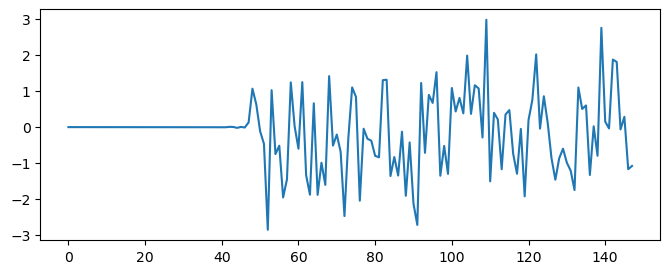

In [126]:
U, s, Vt = np.linalg.svd((Wfree)); rord = argsort(U[:,0]); cord = argsort(Vt[0,:])
Ul, sl, Vtl = np.linalg.svd(Wlat); rord_l = argsort(Ul[:,0]); cord_l = argsort(Vtl[0,:])
u = ones(U.shape[0],); plot(U.T @ u)

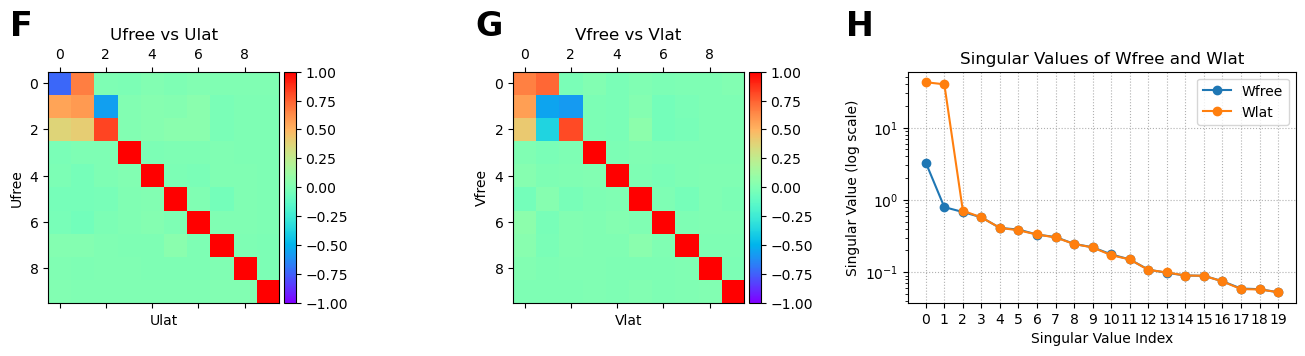

In [125]:
cm_name = "rainbow"
fig, ax = subplots(nrows=1, ncols=3, figsize=(17, 3))
ax[0].matshow((U.T @ Ul)[:10,:10], cmap=cm_name, vmin=-1, vmax=1); ax[0].set_title("Ufree vs Ulat"); ax[0].set_xlabel("Ulat"); ax[0].set_ylabel("Ufree")
ax[1].matshow((Vt @ Vtl.T)[:10,:10], cmap=cm_name, vmin=-1, vmax=1); ax[1].set_title("Vfree vs Vlat"); ax[1].set_xlabel("Vlat"); ax[1].set_ylabel("Vfree")
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax[0]); cax = divider.append_axes("right", size="5%", pad=0.05); fig.colorbar(cm.ScalarMappable(cmap=cm_name, norm=Normalize(vmin=-1, vmax=1)), cax=cax, orientation="vertical")
divider = make_axes_locatable(ax[1]); cax = divider.append_axes("right", size="5%", pad=0.05); fig.colorbar(cm.ScalarMappable(cmap=cm_name, norm=Normalize(vmin=-1, vmax=1)), cax=cax, orientation="vertical")
ax[2].semilogy(s[:20], "o-", label="Wfree"); ax[2].plot(sl[:20], "o-",label="Wlat"); ax[2].set_xlabel("Singular Value Index"); ax[2].set_ylabel("Singular Value (log scale)")
ax[2].set_xticks(np.arange(0, 20, 1)); ax[2].set_title("Singular Values of Wfree and Wlat"); ax[2].legend(); ax[2].grid(True, linestyle=":")
label_axes(ax, labs=list("FGH"), fontsize=24, fontweight="bold", align_y =[[0,1,2]])

There is agreement until the noise floor.

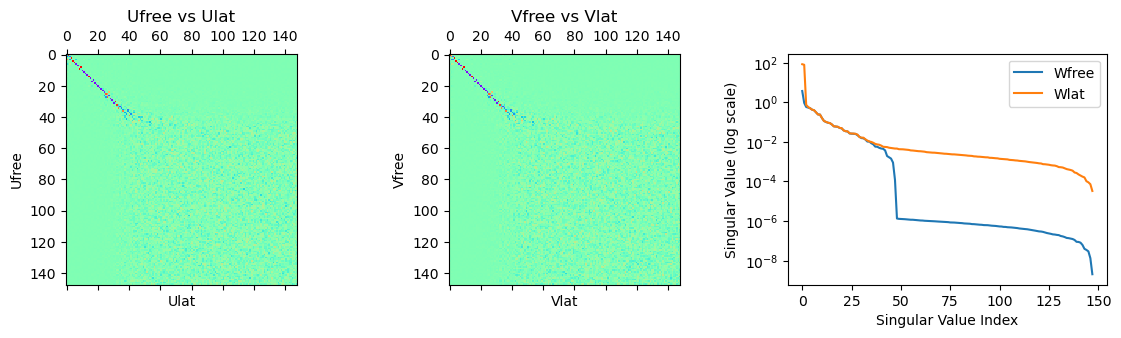

In [95]:
fig, ax = subplots(nrows=1, ncols=3, figsize=(14, 3))
ax[0].matshow((U.T @ Ul), cmap=cm_name, vmin=-1, vmax=1); ax[0].set_title("Ufree vs Ulat"); ax[0].set_xlabel("Ulat"); ax[0].set_ylabel("Ufree")
ax[1].matshow((Vt @ Vtl.T), cmap=cm_name, vmin=-1, vmax=1); ax[1].set_title("Vfree vs Vlat"); ax[1].set_xlabel("Vlat"); ax[1].set_ylabel("Vfree")
ax[2].semilogy(s, label="Wfree"); ax[2].plot(sl, label="Wlat"); ax[2].set_xlabel("Singular Value Index"); ax[2].set_ylabel("Singular Value (log scale)"); ax[2].legend()

The solution for the lower modes is symmetric for both. The upper modes are symmetric in Free, antisymmetric in Lat.

In [96]:
irest = 2
Wfree_head = U[:, :irest] @ np.diag(s[:irest]) @ Vt[:irest, :]
Wlat_head = Ul[:, :irest] @ np.diag(sl[:irest]) @ Vtl[:irest, :]
Wfree_rest = U[:, irest:] @ np.diag(s[irest:]) @ Vt[irest:, :]
Wlat_rest = Ul[:, irest:] @ np.diag(sl[irest:]) @ Vtl[irest:, :]

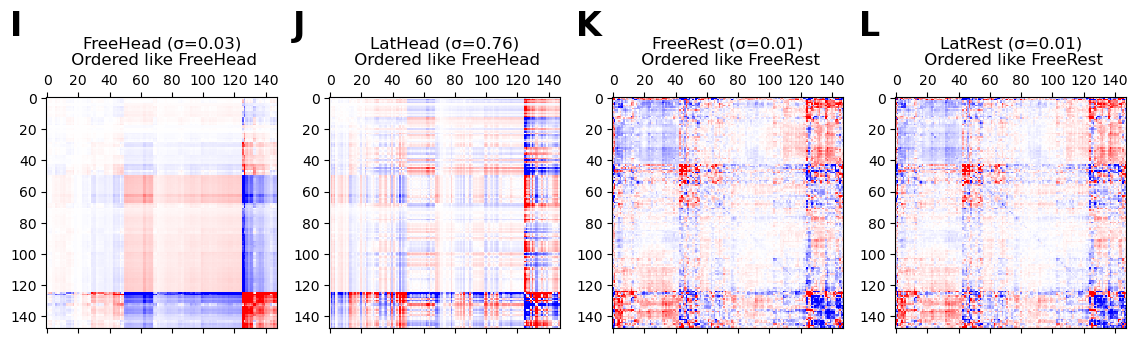

In [97]:
W = {"FreeHead": Wfree_head, "FreeRest": Wfree_rest, "LatHead": Wlat_head, "LatRest": Wlat_rest}
plot_order = ["FreeHead", "LatHead", "FreeRest", "LatRest"]
row_order = {name: get_row_col_order(W[name])[0] for name in plot_order}
fig, ax = subplots(nrows=1, ncols=4, figsize=(14, 3))
for i, name in enumerate(plot_order):
    axi = ax[i]
    which_ord = "FreeHead" if "Head" in name else "FreeRest"
    rord = row_order[which_ord]
    vlim = 3 * W[name].std()
    matshow_kwargs = {"vmin": -vlim, "vmax": vlim, "cmap": "bwr"}
    axi.matshow(W[name][rord, :][:, rord], **matshow_kwargs)
    axi.set_title(f"{name} (σ={W[name].std():.2f})\n Ordered like {which_ord}")
label_axes(ax, labs=list("IJKL"), fontsize=24, fontweight="bold", align_y =[[0,1,2,3]])

# Older stuff

In [63]:
res = split.model("DiagOnlyInh")
in_file = os.path.join(res.base_dir, "in.0.p")
assert os.path.exists(in_file), f"Input file {in_file} does not exist"
with open(in_file, "rb") as f:
    in_data = pickle.load(f)

In [65]:
res = driver.run(in_data, return_dataset=True)

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[29, 4, 26, 30, 32, 37, 34, 40, 7, 10, 11, 31, 33, 27, 47, 2, 46, 18, 15, 28, 22, 16, 41, 20, 42, 8, 13, 25, 5, 17, 35, 14, 38, 1, 12, 43, 24, 6, 23, 36, 21, 19, 9, 39, 45, 3, 0, 44]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(0.001)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
Running minimization with 21

In [71]:
res[1]["YY"].vld.mean(axis=0)

array([1.43478178, 0.61320465, 0.48908943, 1.39906745, 1.58151352,
       0.84660739, 0.52745161, 1.05421893, 0.80238212, 0.33155302,
       0.49475047, 0.7229036 , 0.2948155 , 0.5214803 , 0.44870287,
       0.39750749, 0.23453235, 0.164649  , 0.47122298, 0.32146904,
       0.38172973, 0.3843232 , 0.22735937, 0.26762316, 0.59556648,
       0.22194536, 0.24324698, 0.22042761, 0.74907959, 0.44510239,
       0.70601776, 0.6288188 , 0.68652833, 0.78771584, 0.490638  ,
       0.38097267, 0.2141631 , 0.22396012, 0.24983091, 0.42459542,
       0.61700482, 0.4857581 , 1.04877789, 0.4734942 , 0.6742675 ,
       0.23951927, 1.00871793, 1.13622371])

In [343]:
in_data["min_args"]["p_init"]

'[(i,1e-3) for i in range(-2,3)] * 3'

In [402]:
out_file = in_file.replace("in.0.p", "out.0.p").replace("fit_diag__inh_only", "ffree_lat")
print(f"Output file: {out_file}")
with open(out_file, "rb") as f:
    out_data = pickle.load(f)

Output file: /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/ffree_lat/out.0.p


0: p0 = -0.20001422837620006
1: p0 = -0.10005335711752633
2: p0 = -5.290545440230701e-05
3: p0 = 0.10007776567079156
4: p0 = 0.20017101214682098
5: p0 = -0.19993538524950902
6: p0 = -0.0998600755258613
7: p0 = 2.390491847695129e-05
8: p0 = 0.09996629018988241
9: p0 = 0.19999579131184728


(0.0, 100.0)

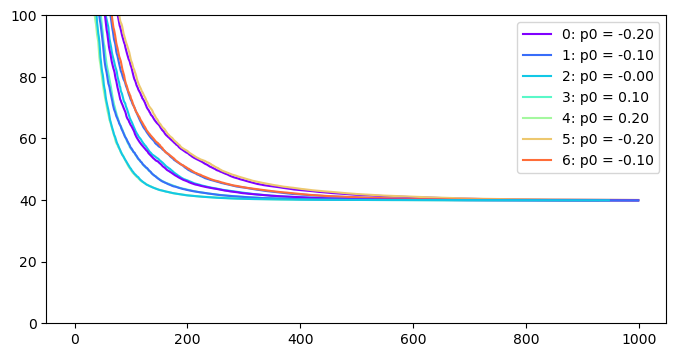

In [403]:
figure(figsize=(8, 4))
for i, run in enumerate(out_data["results"]["all_runs"]):
    p0 = run["p0"]
    print(f"{i}: p0 = {p0.mean()}")
    h = run["history"]
    plot(h["f"], color = cm.rainbow((i % 7)/7.), label = f"{i}: p0 = {p0.mean():.2f}" if i < 7 else None)
legend()
ylim(0,100)


In [344]:
res_ex = res.extract(seed=0, train=0, metric=selection_metric, with_params=True)

In [349]:
res._file_cache.keys()

dict_keys(['out.5.p'])

In [347]:
in_file

'/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/fit_diag__inh_only/in.0.p'

In [346]:
res_ex.params.keys()

dict_keys(['p_init', 'p_final', 'mdl.results', 'history'])

In [338]:
in_data["min_args"]["p0"] = -1 + 0*pfinals_inh[9] + 0.001 * np.random.randn(*pfinals_inh[9].shape) 
results = driver.run(in_data)

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(0.001)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
RUNNING MINIMIZATION using m

In [339]:
res_ex = res.extract(seed=1, train=0, metric="ratio", with_params=True)

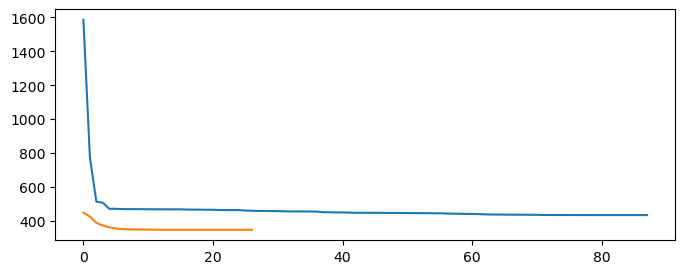

In [340]:
plot(res_ex.params["history"]["cov"])
plot(results["history"]["cov"][2:])

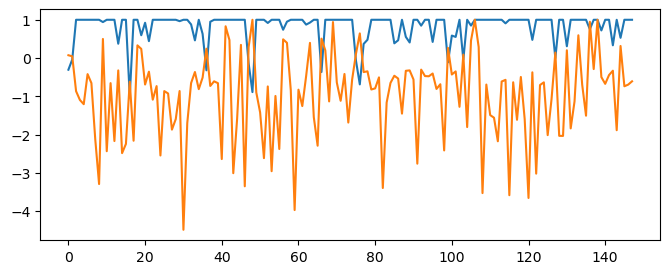

In [341]:
plot(res_ex.params["p_final"])
plot(results["p_final"])

In [337]:
results["history"]["cov"][-1], res_ex.params["history"]["cov"][-1]

(np.float64(346.75487399856837), np.float64(435.75540838694))